# Creative Gaming: Uplift Modeling


In [ ]:
import polars as pl
import pyrsm as rsm

In [138]:
# update pyrsm to version 2.3.0
!uv --project /opt/base-uv add pyrsm==2.3.0

Resolved 220 packages in 19ms
Audited 203 packages in 6ms


In [141]:
## loading the treatment data - this dataset must NOT be changed
cg_ad_treatment = pl.read_parquet("data/cg_ad_treatment.parquet")
cg_ad_treatment.head()

converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,TimesLostSpaceship,TimesKilled,TimesCaptain,TimesNavigator,PurchasedCoinPackSmall,PurchasedCoinPackLarge,NumAdsClicked,DaysUser,UserConsole,UserHasOldOS,rnd_30k
cat,i32,i32,i32,i32,i32,i32,i32,cat,cat,i32,i32,i32,i32,cat,cat,i32,i32,cat,cat,i32
"""no""",6,16,0,0,0,0,0,"""yes""","""no""",0,0,0,0,"""no""","""no""",11,1827,"""no""","""no""",0
"""no""",2,8,0,0,0,5,4,"""no""","""no""",0,0,8,0,"""yes""","""no""",3,1889,"""no""","""yes""",1
"""no""",6,1,0,0,0,0,0,"""no""","""no""",0,0,0,0,"""no""","""yes""",2,1948,"""yes""","""no""",0
"""yes""",7,16,0,102,1,0,194,"""no""","""no""",0,0,0,0,"""yes""","""yes""",21,3409,"""yes""","""yes""",0
"""no""",10,1,1,233,0,23,0,"""no""","""no""",3,0,5,0,"""no""","""yes""",4,2922,"""yes""","""no""",0


In [142]:
rsm.md("data/cg_ad_treatment_description.md")

## Creative gaming

Game telemetry dataset used for the Creative Gaming: Propensity-to-Buy Modeling case

#### Feature descriptions

* converted: Purchased the Zalon campain ("yes" or "no")
* GameLevel: Highest level of game achieved by the user
* NumGameDays: Number of days user played the game in last month (with or without network connection)
* NumGameDays4Plus: Number of days user played the game in last month with 4 or more total users (this implies using a network connection)
* NumInGameMessagesSent: Number of in-game messages sent to friends
* NumFriends: Number of friends to which the user is connected (necessary to crew together in multiplayer mode) 
* NumFriendRequestIgnored: Number of friend requests this user has not replied to since game inception
* NumSpaceHeroBadges: Number of "Space Hero" badges, the highest distinction for gameplay in Space Pirates
* AcquiredSpaceship: Flag if the user owns a spaceship, i.e., does not have to crew on another user's or NPC's space ship ("no" or "yes")
* AcquiredIonWeapon: Flag if the user owns the powerful "ion weapon" ("no" or "yes")
* TimesLostSpaceship: The number of times the user destroyed his/her spaceship during gameplay. Spaceships need to be re-acquired if destroyed.
* TimesKilled: Number of times the user was killed during gameplay
* TimesCaptain: Number of times in last month that the user played in the role of a captain
* TimesNavigator: Number of times in last month that the user played in the role of a navigator
* PurchasedCoinPackSmall: Flag if the user purchased a small pack of Zathium in last month ("no" or "yes")
* PurchasedCoinPackLarge: Flag if the user purchased a large pack of Zathium in last month ("no" or "yes")
* NumAdsClicked: Number of in-app ads the user has clicked on
* DaysUser: Number of days since user established a user ID with Creative Gaming (for Space Pirates or previous games)
* UserConsole: Flag if the user plays Creative Gaming games on a console ("no" or "yes")
* UserHasOldOS: Flag if the user has iOS version 10 or earlier ("no" or "yes")
* rnd_30k: Dummy variable that randomly selects 30K customers (1) and the remaining 90K (0)


#### I.1 Prepare the data

In [145]:
# a
cg_ad_random = cg_ad_random.with_columns(pl.lit(1).alias("ad"))
# b
cg_organic_control = cg_organic_control.with_columns(pl.lit(0).alias("ad"))
# c
cg_rct_stacked = pl.concat([cg_organic_control, cg_ad_random], how="vertical")

In [146]:
# d
cg_rct_stacked = cg_rct_stacked.with_columns(
    training=rsm.model.make_train(cg_rct_stacked, strat_var=["converted", "ad"]),
    test_size=0.3,
    random_state=1234,
)
# e
counts = cg_rct_stacked.group_by(["converted", "ad", "training"]).len()
totals = cg_rct_stacked.group_by(["ad", "training"]).len().rename({"len": "total"})
(
    counts.join(totals, on=["ad", "training"])
    .with_columns((pl.col("len") / pl.col("total")).round(2).alias("prop"))
    .select(["converted", "ad", "training", "prop"])
    .sort(["ad", "training", "converted"])
    .pivot(on=["ad", "training"], index="converted", values="prop")
)

converted,"{0,0}","{0,1}","{1,0}","{1,1}"
cat,f64,f64,f64,f64
"""no""",0.94,0.94,0.87,0.87
"""yes""",0.06,0.06,0.13,0.13


#### I.2 Train a uplift model with Logistic model

In [147]:
cg_rct_stacked.group_by(["ad", "training"]).len().sort(["ad", "training"]).pivot(
    on="training", index="ad", values="len"
)


ad,0,1
i32,u32,u32
0,6000,24000
1,6000,24000


In [148]:
evar = cg_rct_stacked.columns
evar = evar[evar.index("GameLevel") : evar.index("UserHasOldOS") + 1]
evar


['GameLevel',
 'NumGameDays',
 'NumGameDays4Plus',
 'NumInGameMessagesSent',
 'NumSpaceHeroBadges',
 'NumFriendRequestIgnored',
 'NumFriends',
 'AcquiredSpaceship',
 'AcquiredIonWeapon',
 'TimesLostSpaceship',
 'TimesKilled',
 'TimesCaptain',
 'TimesNavigator',
 'PurchasedCoinPackSmall',
 'PurchasedCoinPackLarge',
 'NumAdsClicked',
 'DaysUser',
 'UserConsole',
 'UserHasOldOS']

In [149]:
clf_treatment = rsm.model.logistic(
    data={
        "cg_rct_stacked": cg_rct_stacked.filter(
            (pl.col("training") == 1) & (pl.col("ad") == 1)
        )
    },
    rvar="converted",
    lev="yes",
    evar=evar,
)
clf_treatment.summary()


Logistic regression (GLM)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Null hyp.: There is no effect of x on converted
Alt. hyp.: There is an effect of x on converted

┌─────────────────────────────┬───────┬────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index                       ┆ OR    ┆ OR%    ┆ coefficient ┆ std.error ┆ z.value ┆ p.value ┆     │
╞═════════════════════════════╪═══════╪════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept                   ┆ 0.031 ┆ -96.9% ┆ -3.489      ┆ 0.118     ┆ -29.663 ┆ < .001  ┆ *** │
│ AcquiredSpaceship[no]       

In [150]:
clf_control = rsm.model.logistic(
    data={
        "cg_rct_stacked": cg_rct_stacked.filter(
            (pl.col("training") == 1) & (pl.col("ad") == 0)
        )
    },
    rvar="converted",
    lev="yes",
    evar=evar,
)
clf_control.summary()


Logistic regression (GLM)
Data                 : cg_rct_stacked
Response variable    : converted
Level                : yes
Explanatory variables: GameLevel, NumGameDays, NumGameDays4Plus, NumInGameMessagesSent, NumSpaceHeroBadges, NumFriendRequestIgnored, NumFriends, AcquiredSpaceship, AcquiredIonWeapon, TimesLostSpaceship, TimesKilled, TimesCaptain, TimesNavigator, PurchasedCoinPackSmall, PurchasedCoinPackLarge, NumAdsClicked, DaysUser, UserConsole, UserHasOldOS
Null hyp.: There is no effect of x on converted
Alt. hyp.: There is an effect of x on converted

┌─────────────────────────────┬───────┬────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index                       ┆ OR    ┆ OR%    ┆ coefficient ┆ std.error ┆ z.value ┆ p.value ┆     │
╞═════════════════════════════╪═══════╪════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept                   ┆ 0.012 ┆ -98.8% ┆ -4.407      ┆ 0.191     ┆ -23.032 ┆ < .001  ┆ *** │
│ AcquiredSpaceship[no]       

In [151]:
cg_rct_stacked = cg_rct_stacked.with_columns(
    [
        pl.Series(
            "pred_treatment", clf_treatment.predict(cg_rct_stacked)["prediction"]
        ),
        pl.Series("pred_control", clf_control.predict(cg_rct_stacked)["prediction"]),
    ]
)
cg_rct_stacked.head()

converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,TimesLostSpaceship,TimesKilled,TimesCaptain,TimesNavigator,PurchasedCoinPackSmall,PurchasedCoinPackLarge,NumAdsClicked,DaysUser,UserConsole,UserHasOldOS,ad,training,test_size,random_state,pred_treatment,pred_control
cat,i32,i32,i32,i32,i32,i32,i32,cat,cat,i32,i32,i32,i32,cat,cat,i32,i32,cat,cat,i32,i64,f64,i32,f64,f64
"""no""",7,18,0,124,0,81,0,"""yes""","""no""",8,0,0,4,"""no""","""yes""",3,2101,"""no""","""no""",0,1,0.3,1234,0.081256,0.019853
"""no""",10,3,2,60,0,18,479,"""no""","""no""",10,7,0,0,"""yes""","""no""",7,1644,"""yes""","""no""",0,1,0.3,1234,0.183608,0.034446
"""no""",2,1,0,0,0,0,0,"""no""","""no""",0,0,0,2,"""no""","""no""",8,3197,"""yes""","""yes""",0,1,0.3,1234,0.049103,0.01175
"""no""",2,11,1,125,0,73,217,"""no""","""no""",0,0,0,0,"""yes""","""no""",6,913,"""no""","""no""",0,0,0.3,1234,0.091106,0.010709
"""no""",8,15,0,0,0,6,51,"""yes""","""no""",0,0,2,1,"""yes""","""no""",21,2009,"""yes""","""no""",0,1,0.3,1234,0.308857,0.084095


In [152]:
cg_rct_stacked = cg_rct_stacked.with_columns(
    (pl.col("pred_treatment") - pl.col("pred_control")).alias("uplift_score")
)

#### I.3

In [153]:
help(rsm.model.uplift_tab)

Help on function uplift_tab in module pyrsm.model.perf:

uplift_tab(df, rvar, lev, pred, tvar, tlev, scale=1, qnt=10)
    Calculate an Uplift table

    Parameters
    ----------
    df : Pandas or Polars dataframe
    rvar : str
        Name of the response variable column in df
    lev : str
        Name of the 'success' level in rvar
    pred : str
        Name of the column in df with model predictions
    tvar : str
        Name of the treatment variable column in df
    tlev : str
        Name of the 'success' level in tvar
    scale : float
        Scaling factor to use in calculations
    qnt : int
        Number of quantiles to create

    Returns
    -------
    Polars dataframe
        Incremental uplift per quantile. Input for uplift charts



In [154]:
tab_uplift = rsm.model.uplift_tab(
    cg_rct_stacked.filter(pl.col("training") == 0),
    "converted",
    "yes",
    "uplift_score",
    "ad",
    1,
    qnt=20,
)
tab_uplift

pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
str,i64,f64,u32,u32,u32,u32,f64,f64,f64
"""uplift_score""",1,0.05,132,300,49,417,96.748201,1.61247,0.322494
"""uplift_score""",2,0.1,213,600,68,779,160.62516,2.677086,0.217514
"""uplift_score""",3,0.15,293,900,86,1120,223.892857,3.731548,0.213881
"""uplift_score""",4,0.2,354,1200,104,1448,267.812155,4.463536,0.148455
"""uplift_score""",5,0.25,400,1500,112,1780,305.617978,5.093633,0.129237
…,…,…,…,…,…,…,…,…,…
"""uplift_score""",16,0.8,671,4800,212,5224,476.206738,7.936779,0.041111
"""uplift_score""",17,0.85,695,5100,220,5506,491.222303,8.187038,0.051631
"""uplift_score""",18,0.9,714,5400,246,5757,483.25482,8.054247,-0.040252


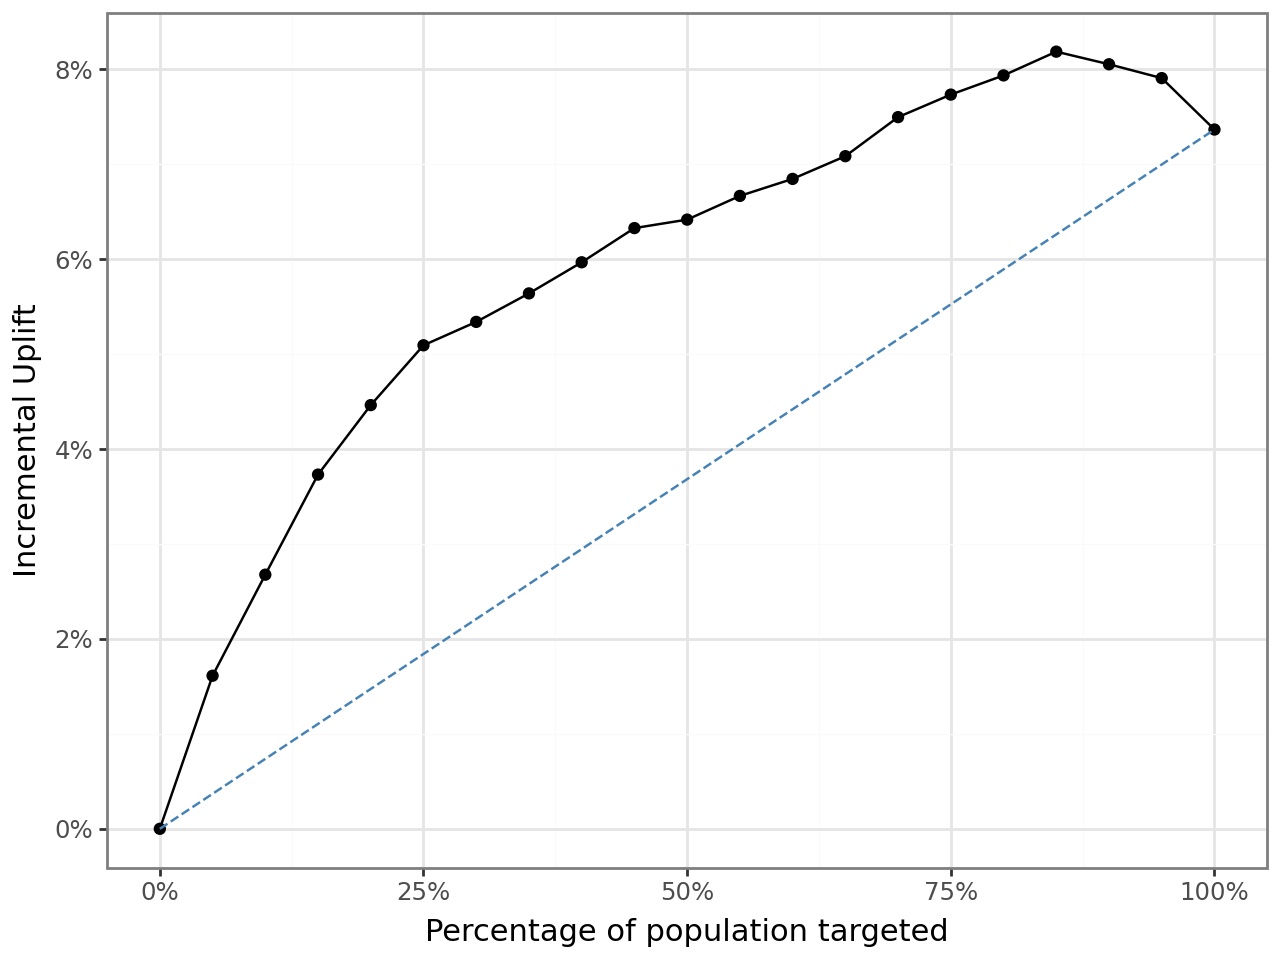

In [155]:
rsm.model.inc_uplift_plot(
    cg_rct_stacked.filter(pl.col("training") == 0),
    "converted",
    "yes",
    "uplift_score",
    "ad",
    1,
    qnt=20,
)


*interpret：*
The cumulative incremental uplift curve lies substantially above the random targeting baseline, confirming that the model meaningfully improves targeting efficiency. The curve peaks around 80% of the population, after which performance declines due to negative uplift segments. This suggests that targeting the entire population is suboptimal, and a selective strategy would maximize incremental impact.

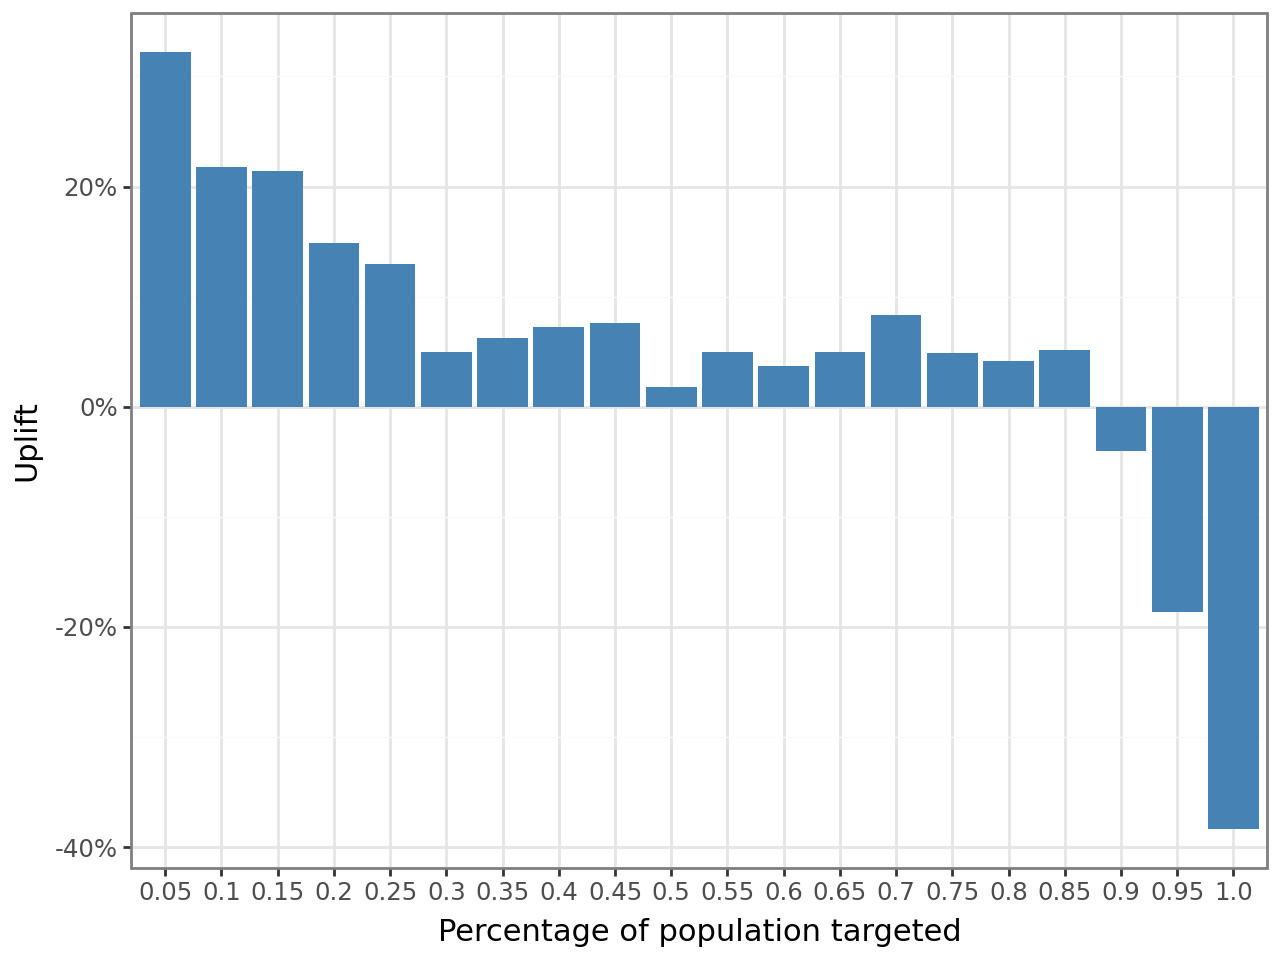

In [156]:
rsm.model.uplift_plot(
    cg_rct_stacked.filter(pl.col("training") == 0),
    "converted",
    "yes",
    "uplift_score",
    "ad",
    1,
    qnt=20,
)


*Interpret：*
The uplift bar chart shows that the model successfully ranks customers by treatment effect. The top 20% of customers exhibit very high positive uplift (above 20%), indicating strong persuadable segments. In contrast, the last decile shows negative uplift, meaning that advertising to those customers would reduce conversions.

#### I.4

In [157]:
population_total = 120_000
target_customers = 30_000
revenue_per_sale = 14.99
cost_per_target = 1.50

target_prop = target_customers / population_total
row = (
    tab_uplift.with_columns((pl.col("cum_prop") - target_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test = row.select("incremental_resp").item()
t_n_test = row.select("T_n").item()

inc_30000 = inc_test * (target_customers / t_n_test)

revenue = inc_30000 * revenue_per_sale
cost = target_customers * cost_per_target
profit = revenue - cost

print("T_n at target in tab:", t_n_test)
print("Incremental purchases (extrapolated to 30,000):", inc_30000)
print("Incremental revenue:", revenue)
print("Cost:", cost)
print("Incremental profit:", profit)

T_n at target in tab: 1500
Incremental purchases (extrapolated to 30,000): 6112.359550561798
Incremental revenue: 91624.26966292135
Cost: 45000.0
Incremental profit: 46624.269662921346


#### I.5

In [158]:
tab_prop = rsm.model.uplift_tab(
    cg_rct_stacked.filter(pl.col("training") == 0),
    "converted",
    "yes",
    "pred_treatment",
    "ad",
    1,
    qnt=20,
)
tab_prop

pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
str,i64,f64,u32,u32,u32,u32,f64,f64,f64
"""pred_treatment""",1,0.05,135,300,53,387,93.914729,1.565245,0.313049
"""pred_treatment""",2,0.1,221,600,83,755,155.039735,2.583996,0.205145
"""pred_treatment""",3,0.15,287,900,112,1062,192.084746,3.201412,0.125537
"""pred_treatment""",4,0.2,356,1200,135,1323,233.55102,3.892517,0.141877
"""pred_treatment""",5,0.25,411,1500,166,1570,252.401274,4.206688,0.057827
…,…,…,…,…,…,…,…,…,…
"""pred_treatment""",16,0.8,710,4800,327,4822,384.491912,6.408199,0.052381
"""pred_treatment""",17,0.85,730,5100,332,5104,398.260188,6.63767,0.048936
"""pred_treatment""",18,0.9,746,5400,334,5406,412.370699,6.872845,0.046711


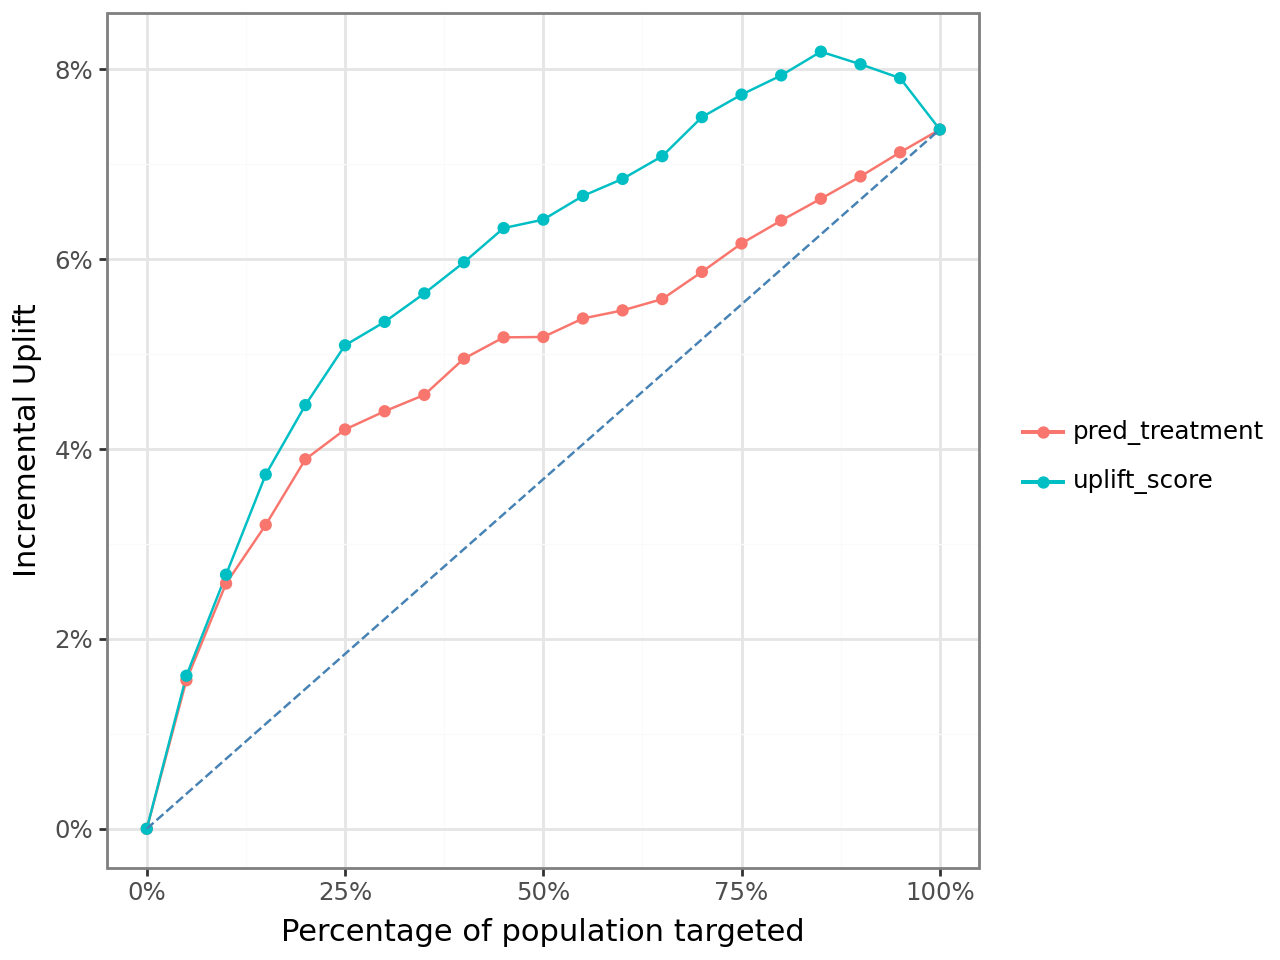

In [159]:
rsm.model.inc_uplift_plot(
    cg_rct_stacked.filter(pl.col("training") == 0),
    "converted",
    "yes",
    ["pred_treatment", "uplift_score"],
    "ad",
    1,
    qnt=20,
)


*interpret:*
The cumulative incremental uplift curve confirms that the uplift model consistently outperforms the propensity model across most targeting levels. The uplift model achieves a higher peak incremental uplift and remains further above the random baseline. This indicates superior targeting efficiency and higher expected incremental profit when selecting the top customers for advertising.

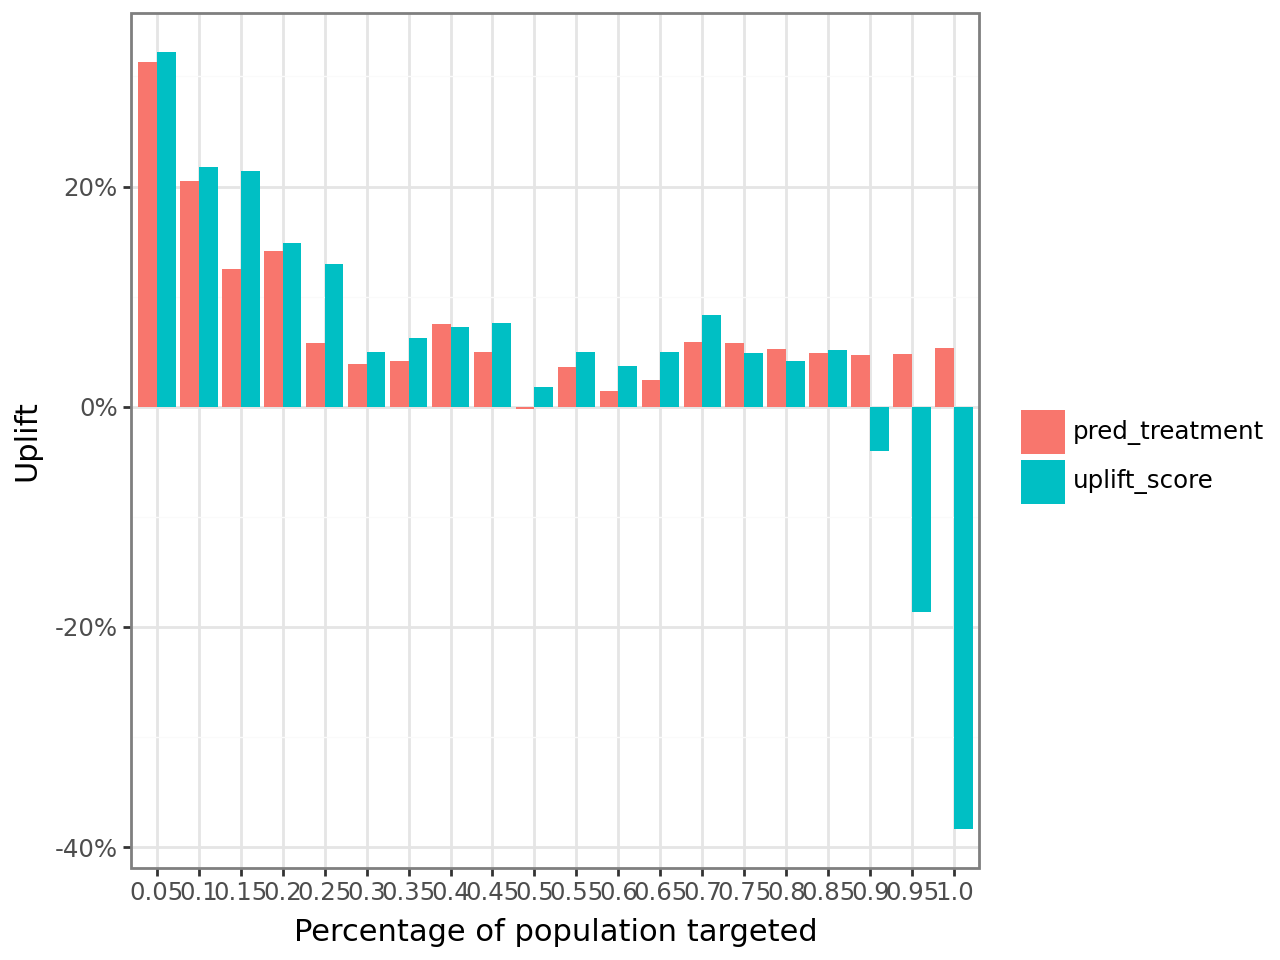

In [160]:
rsm.model.uplift_plot(
    cg_rct_stacked.filter(pl.col("training") == 0),
    "converted",
    "yes",
    ["pred_treatment", "uplift_score"],
    "ad",
    1,
    qnt=20,
)


*interpret:*
The uplift bar chart shows that both models identify high-value customers in the top deciles. However, the propensity model ranks customers by purchase likelihood, it tends to prioritize customers who would purchase regardless of advertising, which resulting in smaller incremental gains. While the uplift model better identifies “persuadable” customers and successfully detects negative-response segments in the lower deciles.

In [161]:
test_data = cg_rct_stacked.filter(pl.col("training") == 0).select(
    ["pred_treatment", "pred_control", "uplift_score"]
)
cm = rsm.basics.correlation({"cg_rct_stacked": test_data})
cm.summary()


Correlation
Data     : cg_rct_stacked
Method   : pearson
Cutoff   : 0
Variables: pred_treatment, pred_control, uplift_score
Null hyp.: variables x and y are not correlated
Alt. hyp.: variables x and y are correlated

Correlation matrix:
┌──────────────┬────────────────┬──────────────┐
│              ┆ pred_treatment ┆ pred_control │
╞══════════════╪════════════════╪══════════════╡
│ pred_control ┆ 0.27           ┆              │
│ uplift_score ┆ 0.55           ┆ -0.66        │
└──────────────┴────────────────┴──────────────┘

p.values:
┌──────────────┬────────────────┬──────────────┐
│              ┆ pred_treatment ┆ pred_control │
╞══════════════╪════════════════╪══════════════╡
│ pred_control ┆ 0.0            ┆              │
│ uplift_score ┆ 0.0            ┆ 0.0          │
└──────────────┴────────────────┴──────────────┘


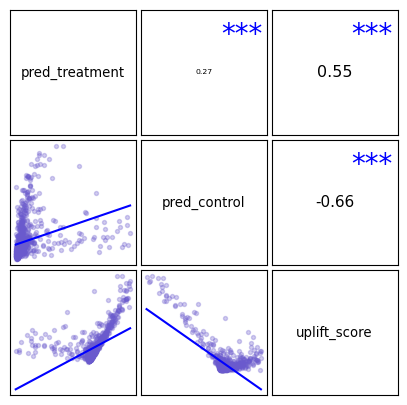

In [162]:
cm.plot()


*interpret：*
pred_treatment and pred_control (ρ = 0.27)
There is a moderate positive correlation, meaning users who are likely to convert under ads also tend to have higher baseline conversion probability. However, the relationship is not strong, indicating that ad response differs across users.

uplift_score and pred_treatment (ρ = 0.55)
Uplift is positively correlated with treatment conversion probability. Users who are more likely to convert when treated tend to have higher incremental impact.

uplift_score and pred_control (ρ = −0.66)
There is a strong negative correlation between uplift and baseline conversion probability. Users who would convert anyway (high baseline probability) tend to have low incremental gain from advertising.

#### I.6

In [163]:
row_p = (
    tab_prop.with_columns((pl.col("cum_prop") - target_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)
inc_test_p = row_p.select("incremental_resp").item()
t_n_test_p = row_p.select("T_n").item()

inc_30000_p = inc_test_p * (target_customers / t_n_test_p)

revenue_p = inc_30000_p * revenue_per_sale
cost_p = target_customers * cost_per_target
profit_p = revenue_p - cost_p

print("Propensity profit:", profit_p)


Propensity profit: 30669.901910828034


In [164]:
extra_profit = profit - profit_p
print("Extra profit (uplift - propensity):", extra_profit)


Extra profit (uplift - propensity): 15954.367752093312


#### I.7 Neural Network

In [165]:
dtypes = cg_rct_stacked.select(evar).schema
non_numeric = [c for c, dt in dtypes.items() if dt not in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                                                          pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                                                          pl.Float32, pl.Float64)]
print("Non-numeric feature columns in evar:")
print(non_numeric)

Non-numeric feature columns in evar:
['AcquiredSpaceship', 'AcquiredIonWeapon', 'PurchasedCoinPackSmall', 'PurchasedCoinPackLarge', 'UserConsole', 'UserHasOldOS']


In [ ]:
base_cols = ["converted", "ad", "training"]
all_df = cg_rct_stacked.select(base_cols + evar)

schema = all_df.select(evar).schema
cat_cols = [c for c, dt in schema.items() if dt not in (
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
)]

print("Will one-hot encode:", cat_cols)

all_df_enc = all_df.to_dummies(columns=cat_cols)

feature_cols = [c for c in all_df_enc.columns if c not in base_cols]

print("Number of features after encoding:", len(feature_cols))

Will one-hot encode: ['AcquiredSpaceship', 'AcquiredIonWeapon', 'PurchasedCoinPackSmall', 'PurchasedCoinPackLarge', 'UserConsole', 'UserHasOldOS']
Number of features after encoding: 25


In [167]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

train_df_enc = all_df_enc.filter(pl.col("training") == 1)
test_df_enc  = all_df_enc.filter(pl.col("training") == 0)

def make_xy(df: pl.DataFrame):
    X = df.select(feature_cols).to_numpy()
    y = (df.select("converted").to_series() == "yes").cast(pl.Int8).to_numpy()
    return X, y

In [ ]:
def tune_mlp_for_group_fast(train_df: pl.DataFrame, ad_value: int, seed: int = 1234):
    df_g = train_df.filter(pl.col("ad") == ad_value)
    X, y = make_xy(df_g)

    grid_hidden = [(100,), (200,)]
    grid_alpha  = [1e-6, 1e-4, 1e-3]
    grid_lr     = [1e-3, 5e-4]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    best_auc = -1.0
    best_params = None

    for h in grid_hidden:
        for a in grid_alpha:
            for lr in grid_lr:
                aucs = []
                for tr_idx, va_idx in skf.split(X, y):
                    X_tr, X_va = X[tr_idx], X[va_idx]
                    y_tr, y_va = y[tr_idx], y[va_idx]

                    scaler = StandardScaler()
                    X_tr_s = scaler.fit_transform(X_tr)
                    X_va_s = scaler.transform(X_va)

                    clf = MLPClassifier(
                        hidden_layer_sizes=h,
                        alpha=a,
                        learning_rate_init=lr,
                        max_iter=800,
                        solver="adam",
                        random_state=seed,
                        early_stopping=True,
                        n_iter_no_change=20,
                        validation_fraction=0.1
                    )
                    clf.fit(X_tr_s, y_tr)
                    p_va = clf.predict_proba(X_va_s)[:, 1]
                    aucs.append(roc_auc_score(y_va, p_va))

                mean_auc = float(np.mean(aucs))
                if mean_auc > best_auc:
                    best_auc = mean_auc
                    best_params = {
                        "hidden_layer_sizes": h,
                        "alpha": a,
                        "learning_rate_init": lr
                    }

    return best_params, best_auc

In [170]:
best_treat_params, best_treat_auc = tune_mlp_for_group_fast(train_df_enc, ad_value=1, seed=1234)
best_ctrl_params,  best_ctrl_auc  = tune_mlp_for_group_fast(train_df_enc, ad_value=0, seed=1234)

print("Best treatment params:", best_treat_params, "CV AUC:", best_treat_auc)
print("Best control params:",   best_ctrl_params,  "CV AUC:", best_ctrl_auc)

Best treatment params: {'hidden_layer_sizes': (200,), 'alpha': 0.001, 'learning_rate_init': 0.001} CV AUC: 0.7267163530206007
Best control params: {'hidden_layer_sizes': (200,), 'alpha': 1e-06, 'learning_rate_init': 0.0005} CV AUC: 0.8440011942994051


In [171]:
# treatment final
train_treat = train_df_enc.filter(pl.col("ad") == 1)
X_treat, y_treat = make_xy(train_treat)

scaler_treat = StandardScaler()
X_treat_s = scaler_treat.fit_transform(X_treat)

mlp_treat = MLPClassifier(
    hidden_layer_sizes=best_treat_params["hidden_layer_sizes"],
    alpha=best_treat_params["alpha"],
    learning_rate_init=best_treat_params["learning_rate_init"],
    max_iter=400,
    random_state=1234,
    early_stopping=True,
    n_iter_no_change=10
)
mlp_treat.fit(X_treat_s, y_treat)

# control final
train_ctrl = train_df_enc.filter(pl.col("ad") == 0)
X_ctrl, y_ctrl = make_xy(train_ctrl)

scaler_ctrl = StandardScaler()
X_ctrl_s = scaler_ctrl.fit_transform(X_ctrl)

mlp_ctrl = MLPClassifier(
    hidden_layer_sizes=best_ctrl_params["hidden_layer_sizes"],
    alpha=best_ctrl_params["alpha"],
    learning_rate_init=best_ctrl_params["learning_rate_init"],
    max_iter=400,
    random_state=1234,
    early_stopping=True,
    n_iter_no_change=10
)
mlp_ctrl.fit(X_ctrl_s, y_ctrl)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(200,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",1e-06
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.0005
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",400
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1234


In [172]:
X_test, y_test = make_xy(test_df_enc)

X_test_treat_s = scaler_treat.transform(X_test)
X_test_ctrl_s  = scaler_ctrl.transform(X_test)

pred_treatment = mlp_treat.predict_proba(X_test_treat_s)[:, 1]
pred_control   = mlp_ctrl.predict_proba(X_test_ctrl_s)[:, 1]
uplift_score   = pred_treatment - pred_control

test_pred = test_df_enc.with_columns([
    pl.Series("pred_treatment", pred_treatment),
    pl.Series("pred_control", pred_control),
    pl.Series("uplift_score", uplift_score),
])

test_pred.select(["pred_treatment","pred_control","uplift_score"]).head()


pred_treatment,pred_control,uplift_score
f64,f64,f64
0.051578,0.005903,0.045675
0.121304,0.022093,0.099212
0.090876,0.01551,0.075366
0.065073,0.003633,0.06144
0.310763,0.042144,0.268619


In [ ]:
tab_uplift_mlp = rsm.model.uplift_tab(
    test_pred,
    "converted",
    "yes",
    "uplift_score",
    "ad",
    1,
    qnt=20
)

tab_uplift_mlp

pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
str,i64,f64,u32,u32,u32,u32,f64,f64,f64
"""uplift_score""",1,0.05,135,300,44,418,103.421053,1.723684,0.344737
"""uplift_score""",2,0.1,226,600,74,760,167.578947,2.792982,0.215614
"""uplift_score""",3,0.15,302,900,92,1115,227.73991,3.795665,0.202629
"""uplift_score""",4,0.2,373,1200,113,1443,279.029106,4.650485,0.172642
"""uplift_score""",5,0.25,434,1500,124,1771,328.974591,5.48291,0.169797
…,…,…,…,…,…,…,…,…,…
"""uplift_score""",16,0.8,673,4800,215,5176,473.618238,7.893637,0.018182
"""uplift_score""",17,0.85,689,5100,226,5462,477.978396,7.966307,0.014872
"""uplift_score""",18,0.9,715,5400,245,5748,484.832985,8.08055,0.020233


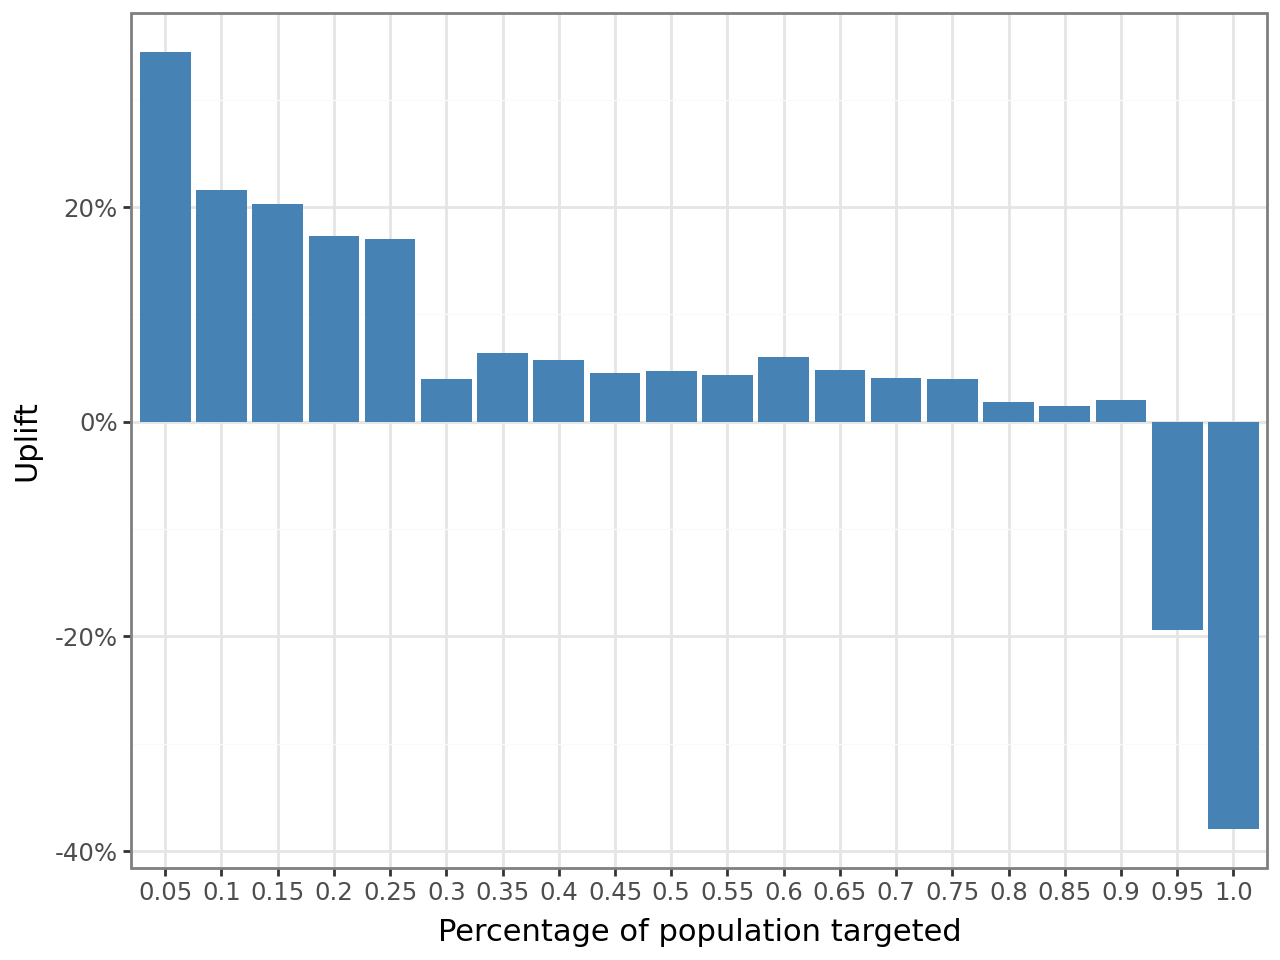

In [ ]:
p_u1 = rsm.model.uplift_plot(
    test_pred,
    rvar="converted",
    lev="yes",
    pred="uplift_score",
    tvar="ad",
    tlev=1,
    qnt=20
)
p_u1

The uplift plot shows that the highest-ranked deciles have clearly positive uplift, especially in the top 5–20% of customers. Uplift gradually decreases as more of the population is targeted and becomes negative in the last bins, indicating that the model successfully identifies persuadable customers while avoiding less responsive segments.

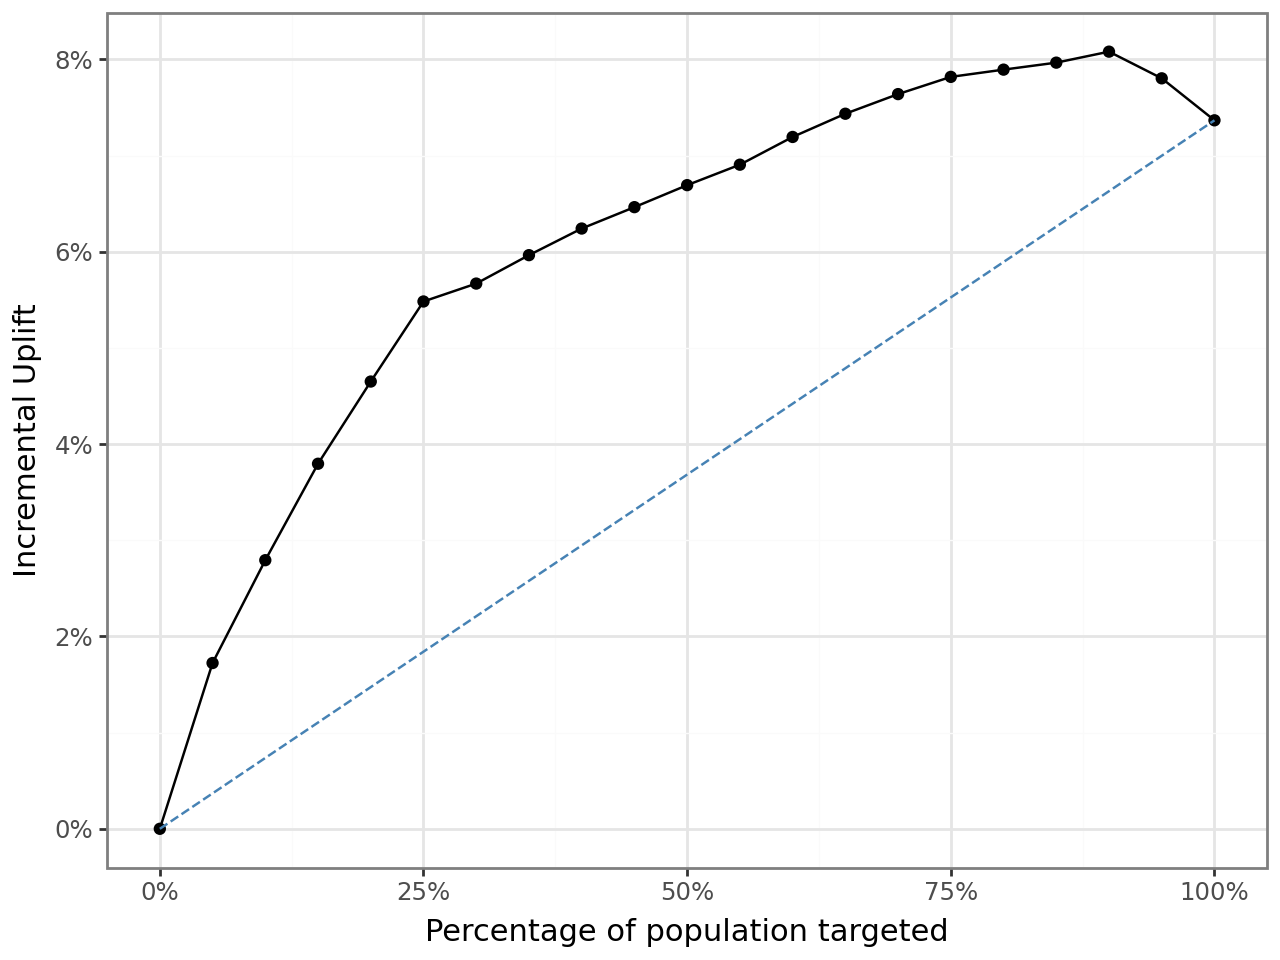

In [175]:
p_u2 = rsm.model.inc_uplift_plot(
    test_pred,
    rvar="converted",
    lev="yes",
    pred="uplift_score",
    tvar="ad",
    tlev=1,
    qnt=20
)
p_u2

The incremental uplift curve increases sharply in the early targeting range and stays well above the random baseline. This suggests that the neural network effectively ranks customers by incremental treatment effect, with diminishing gains as more customers are included.

In [ ]:
revenue_per_sale = 14.99
cost_per_target  = 1.50

target_customers = 30000
target_prop = target_customers / 120000

row_u = (
    tab_uplift_mlp
    .with_columns((pl.col("cum_prop") - target_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_u = row_u.select("incremental_resp").item()
t_n_test_u = row_u.select("T_n").item()

inc_30000_u = inc_test_u * (target_customers / t_n_test_u)

revenue_u = inc_30000_u * revenue_per_sale
cost_u    = target_customers * cost_per_target
profit_u  = revenue_u - cost_u

print("Uplift (MLP) profit:", profit_u)

Uplift (MLP) profit: 53626.582269904015


In [ ]:
tab_prop_mlp = rsm.model.uplift_tab(
    test_pred,
    "converted",
    "yes",
    "pred_treatment",
    "ad",
    1,
    qnt=20
)

tab_prop_mlp

pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
str,i64,f64,u32,u32,u32,u32,f64,f64,f64
"""pred_treatment""",1,0.05,137,300,50,392,98.734694,1.645578,0.329116
"""pred_treatment""",2,0.1,230,600,88,722,156.869806,2.614497,0.194848
"""pred_treatment""",3,0.15,311,900,115,1036,211.096525,3.518275,0.184013
"""pred_treatment""",4,0.2,372,1200,149,1314,235.926941,3.932116,0.081031
"""pred_treatment""",5,0.25,432,1500,173,1616,271.418317,4.523639,0.12053
…,…,…,…,…,…,…,…,…,…
"""pred_treatment""",16,0.8,723,4800,308,4878,419.924969,6.998749,0.029325
"""pred_treatment""",17,0.85,741,5100,319,5187,427.350492,7.122508,0.024401
"""pred_treatment""",18,0.9,755,5400,326,5453,432.168531,7.202809,0.020351


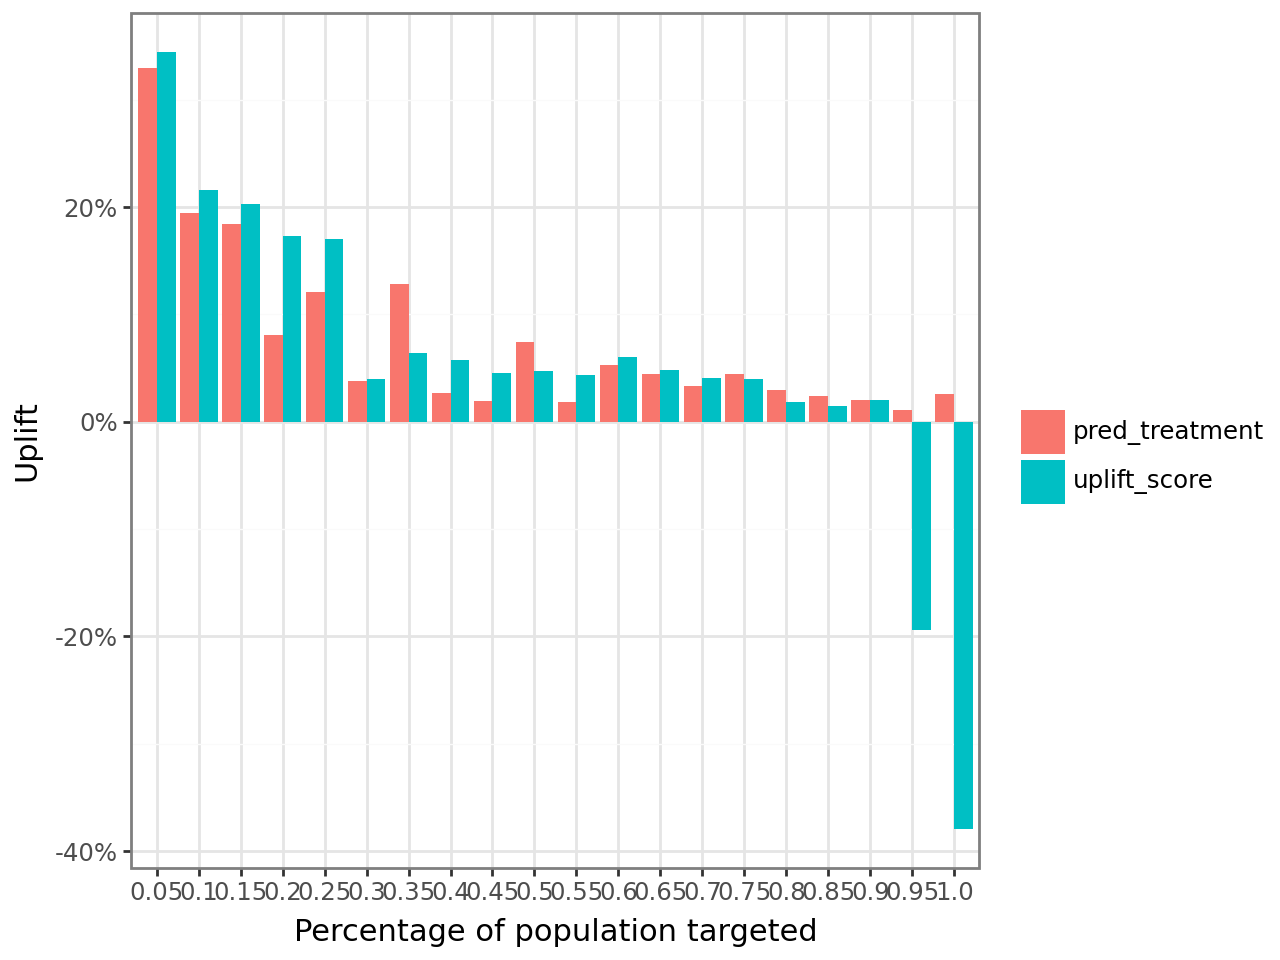

In [ ]:
p_p1 = rsm.model.uplift_plot(
    test_pred,
    rvar="converted",
    lev="yes",
    pred=["pred_treatment", "uplift_score"],
    tvar="ad",
    tlev=1,
    qnt=20
)
p_p1

When ranking customers by propensity instead of uplift, the uplift distribution is less consistent across bins. Although some top segments still show positive uplift, the pattern is more irregular, indicating that the model focuses more on purchase likelihood than true treatment effect.

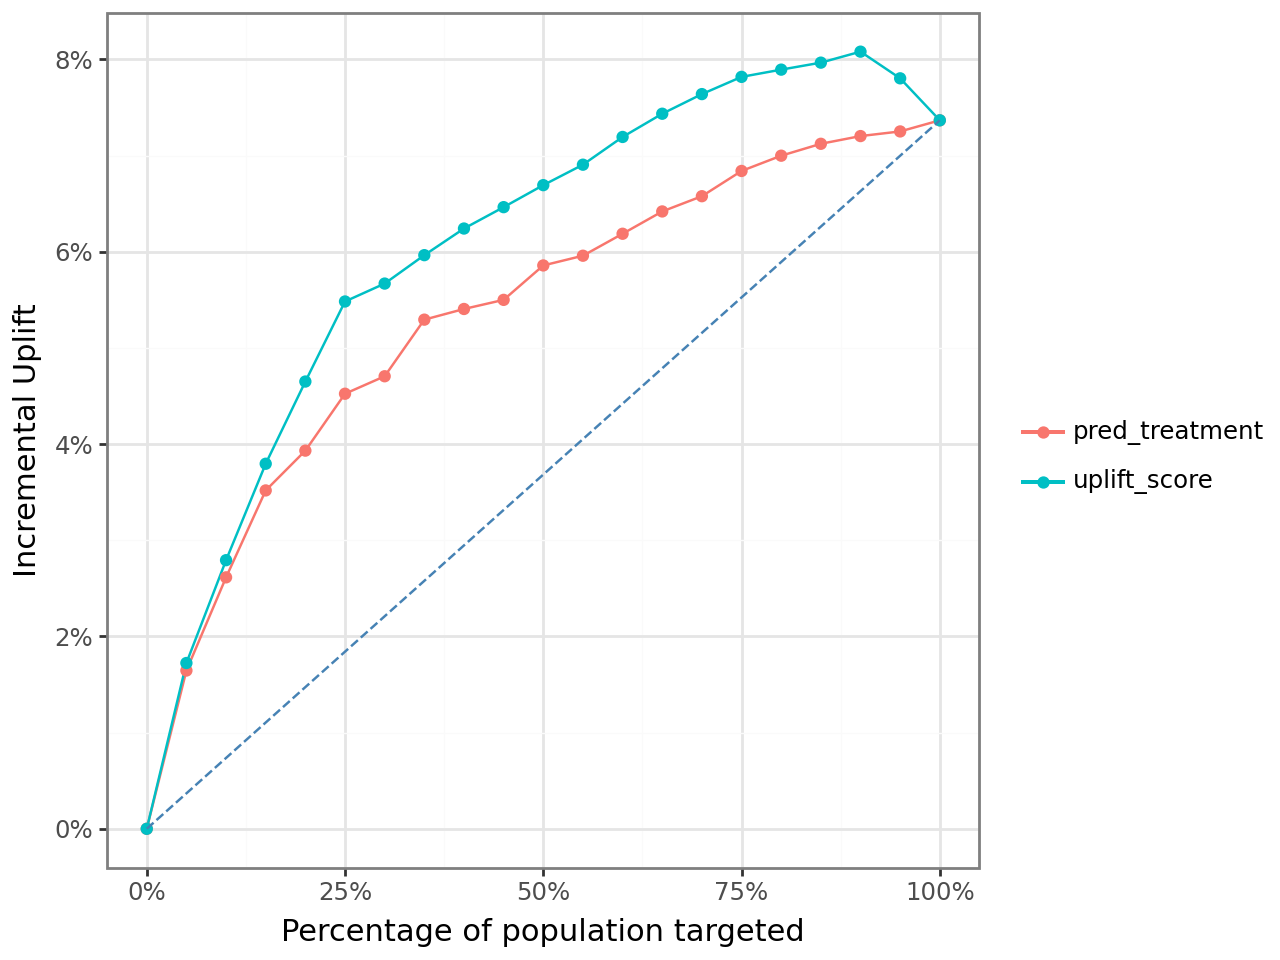

In [179]:
p_p2 = rsm.model.inc_uplift_plot(
    test_pred,
    rvar="converted",
    lev="yes",
    pred=["pred_treatment", "uplift_score"],
    tvar="ad",
    tlev=1,
    qnt=20
)
p_p2

The incremental uplift curve under propensity ranking rises more gradually and stays closer to the random baseline. This indicates that the propensity approach is less effective at maximizing incremental response compared to the uplift-based targeting strategy.

In [180]:
row_p = (
    tab_prop_mlp
    .with_columns((pl.col("cum_prop") - target_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_p = row_p.select("incremental_resp").item()
t_n_test_p = row_p.select("T_n").item()

inc_30000_p = inc_test_p * (target_customers / t_n_test_p)

revenue_p = inc_30000_p * revenue_per_sale
cost_p    = target_customers * cost_per_target
profit_p  = revenue_p - cost_p

print("Propensity (MLP) profit:", profit_p)

extra_profit = profit_u - profit_p
print("Extra profit (uplift - propensity):", extra_profit)

Propensity (MLP) profit: 36371.21138613862
Extra profit (uplift - propensity): 17255.370883765398


In [181]:
test_data_nn = test_pred.select(["pred_treatment","pred_control","uplift_score"])
cm_nn = rsm.basics.correlation({"test_data_nn": test_data_nn})
cm_nn.summary()

Correlation
Data     : test_data_nn
Method   : pearson
Cutoff   : 0
Variables: pred_treatment, pred_control, uplift_score
Null hyp.: variables x and y are not correlated
Alt. hyp.: variables x and y are correlated

Correlation matrix:
┌──────────────┬────────────────┬──────────────┐
│              ┆ pred_treatment ┆ pred_control │
╞══════════════╪════════════════╪══════════════╡
│ pred_control ┆ 0.19           ┆              │
│ uplift_score ┆ 0.64           ┆ -0.63        │
└──────────────┴────────────────┴──────────────┘

p.values:
┌──────────────┬────────────────┬──────────────┐
│              ┆ pred_treatment ┆ pred_control │
╞══════════════╪════════════════╪══════════════╡
│ pred_control ┆ 0.0            ┆              │
│ uplift_score ┆ 0.0            ┆ 0.0          │
└──────────────┴────────────────┴──────────────┘


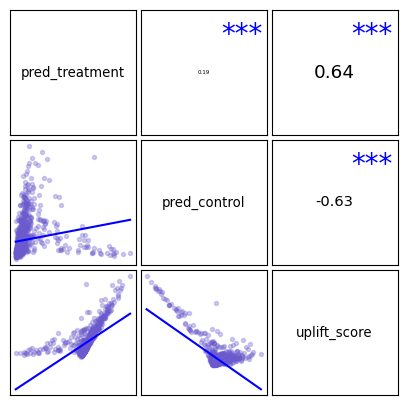

In [182]:
cm_nn.plot()

#### I.8 Random Forest model

In [183]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
def tune_rf_for_group(train_df: pl.DataFrame, ad_value: int, seed: int = 1234):
    df_g = train_df.filter(pl.col("ad") == ad_value)
    X, y = make_xy(df_g)

    grid_n = [100, 200]
    grid_depth = [5, 10, None]
    # grid_leaf = [1, 5]
    grid_leaf = [10, 50, 100]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    best_auc = -1
    best_params = None

    for n in grid_n:
        for d in grid_depth:
            for leaf in grid_leaf:
                aucs = []
                for tr_idx, va_idx in skf.split(X, y):
                    X_tr, X_va = X[tr_idx], X[va_idx]
                    y_tr, y_va = y[tr_idx], y[va_idx]

                    clf = RandomForestClassifier(
                        n_estimators=n,
                        max_depth=d,
                        min_samples_leaf=leaf,
                        random_state=seed,
                        n_jobs=-1
                    )

                    clf.fit(X_tr, y_tr)
                    p_va = clf.predict_proba(X_va)[:, 1]
                    aucs.append(roc_auc_score(y_va, p_va))

                mean_auc = np.mean(aucs)

                if mean_auc > best_auc:
                    best_auc = mean_auc
                    best_params = {
                        "n_estimators": n,
                        "max_depth": d,
                        "min_samples_leaf": leaf
                    }

    return best_params, best_auc


In [185]:
best_treat_params_rf, best_treat_auc_rf = tune_rf_for_group(train_df_enc, ad_value=1)
best_ctrl_params_rf,  best_ctrl_auc_rf  = tune_rf_for_group(train_df_enc, ad_value=0)

print("RF Treatment best:", best_treat_params_rf, "AUC:", best_treat_auc_rf)
print("RF Control best:", best_ctrl_params_rf, "AUC:", best_ctrl_auc_rf)

RF Treatment best: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 10} AUC: 0.783488306586797
RF Control best: {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 10} AUC: 0.8854653924236431


In [186]:
# Treatment
train_treat = train_df_enc.filter(pl.col("ad") == 1)
X_treat, y_treat = make_xy(train_treat)

rf_treat = RandomForestClassifier(
    **best_treat_params_rf,
    random_state=1234,
    n_jobs=-1
)
rf_treat.fit(X_treat, y_treat)

# Control
train_ctrl = train_df_enc.filter(pl.col("ad") == 0)
X_ctrl, y_ctrl = make_xy(train_ctrl)

rf_ctrl = RandomForestClassifier(
    **best_ctrl_params_rf,
    random_state=1234,
    n_jobs=-1
)
rf_ctrl.fit(X_ctrl, y_ctrl)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [187]:
X_test, y_test = make_xy(test_df_enc)

pred_treatment_rf = rf_treat.predict_proba(X_test)[:, 1]
pred_control_rf   = rf_ctrl.predict_proba(X_test)[:, 1]

uplift_score_rf = pred_treatment_rf - pred_control_rf

test_pred_rf = test_df_enc.with_columns([
    pl.Series("pred_treatment", pred_treatment_rf),
    pl.Series("pred_control", pred_control_rf),
    pl.Series("uplift_score", uplift_score_rf),
])

In [188]:
tab_uplift_rf = rsm.model.uplift_tab(
    test_pred_rf,
    "converted",
    "yes",
    "uplift_score",
    "ad",
    1,
    qnt=20
)

tab_uplift_rf

pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
str,i64,f64,u32,u32,u32,u32,f64,f64,f64
"""uplift_score""",1,0.05,146,300,47,404,111.09901,1.85165,0.37033
"""uplift_score""",2,0.1,236,600,71,770,180.675325,3.011255,0.234426
"""uplift_score""",3,0.15,322,900,91,1090,246.862385,4.114373,0.224167
"""uplift_score""",4,0.2,401,1200,110,1433,308.885555,5.148093,0.20794
"""uplift_score""",5,0.25,462,1500,130,1807,354.086331,5.901439,0.149857
…,…,…,…,…,…,…,…,…,…
"""uplift_score""",16,0.8,699,4800,217,5229,499.803213,8.330054,0.025833
"""uplift_score""",17,0.85,703,5100,218,5535,502.132791,8.36888,0.010065
"""uplift_score""",18,0.9,725,5400,252,5799,490.338852,8.172314,-0.055455


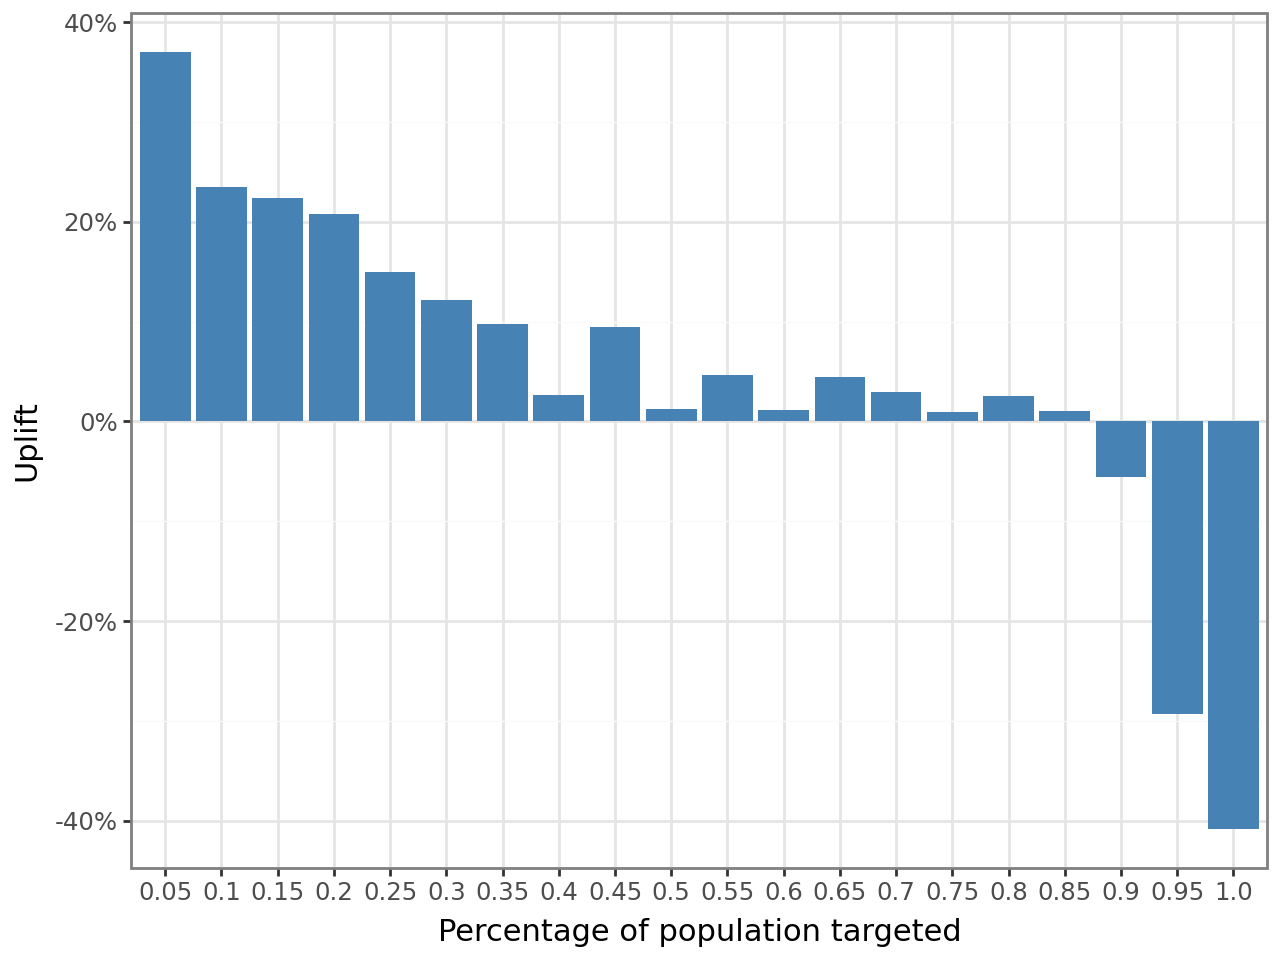

In [189]:
rsm.model.uplift_plot(
    test_pred_rf,
    rvar="converted",
    lev="yes",
    pred="uplift_score",
    tvar="ad",
    tlev=1,
    qnt=20
)

The uplift plot for the Random Forest model shows strong positive uplift in the top deciles, especially within the first 20% of customers. Uplift declines gradually as more of the population is targeted and becomes negative in the last bins, indicating that the model effectively identifies persuadable customers while avoiding segments that may respond negatively.

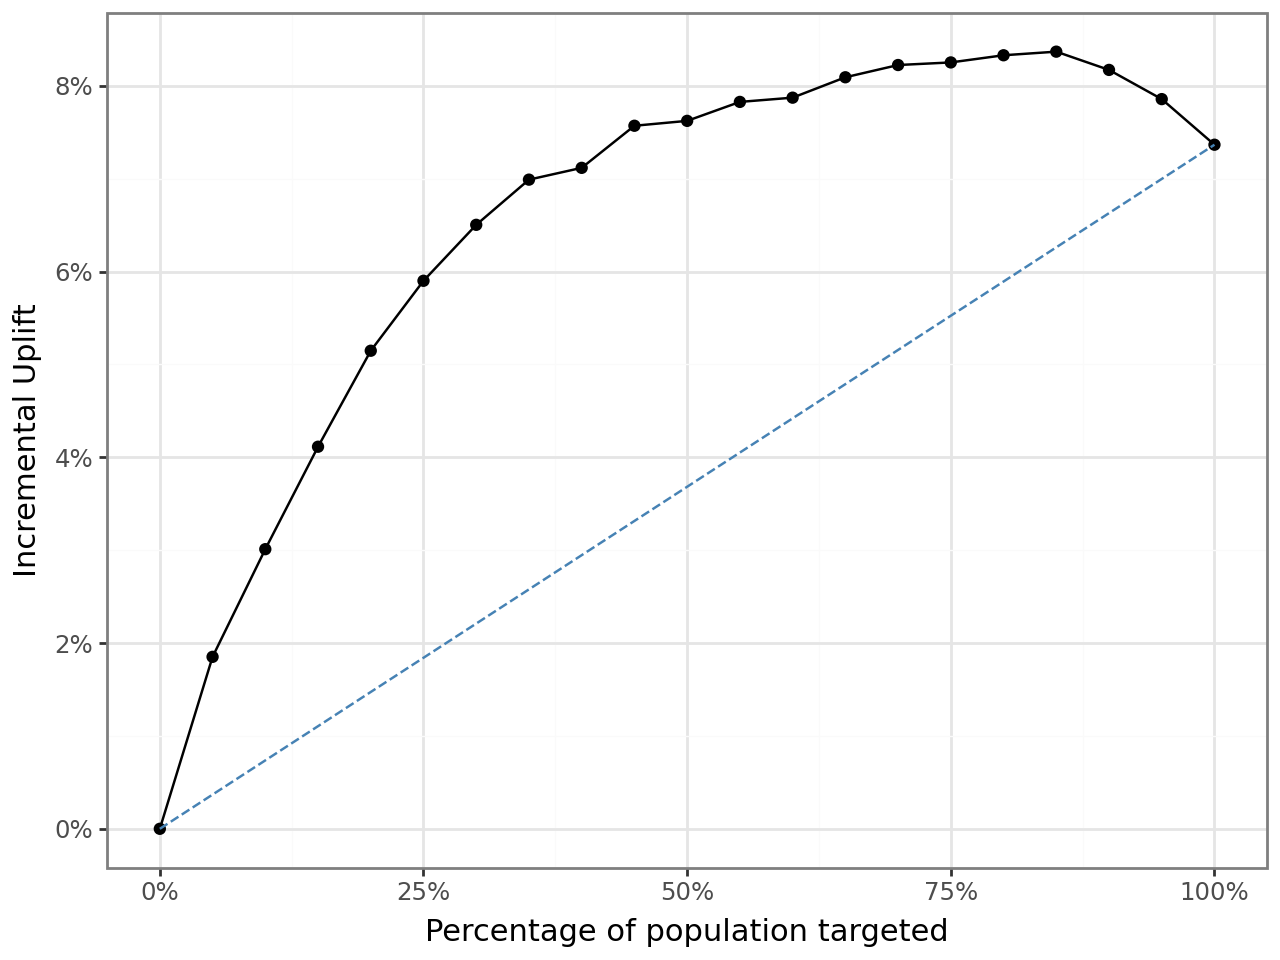

In [190]:
rsm.model.inc_uplift_plot(
    test_pred_rf,
    rvar="converted",
    lev="yes",
    pred="uplift_score",
    tvar="ad",
    tlev=1,
    qnt=20
)

The incremental uplift curve rises steeply in the early targeting range and remains clearly above the random baseline. This suggests that the Random Forest model ranks customers effectively by incremental treatment effect, with diminishing marginal gains as the targeting proportion increases.

In [191]:
row_rf = (
    tab_uplift_rf
    .with_columns((pl.col("cum_prop") - target_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_rf = row_rf.select("incremental_resp").item()
t_n_test_rf = row_rf.select("T_n").item()

inc_30000_rf = inc_test_rf * (target_customers / t_n_test_rf)

revenue_rf = inc_30000_rf * revenue_per_sale
cost_rf    = target_customers * cost_per_target
profit_rf  = revenue_rf - cost_rf

print("RF Uplift profit:", profit_rf)

RF Uplift profit: 61155.08201438848


In [192]:
tab_prop_rf = rsm.model.uplift_tab(
    test_pred_rf,
    "converted",
    "yes",
    "pred_treatment",
    "ad",
    1,
    qnt=20
)
tab_prop_rf

pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
str,i64,f64,u32,u32,u32,u32,f64,f64,f64
"""pred_treatment""",1,0.05,151,300,62,410,105.634146,1.760569,0.352114
"""pred_treatment""",2,0.1,240,600,89,738,167.642276,2.794038,0.21435
"""pred_treatment""",3,0.15,331,900,120,1045,227.650718,3.794179,0.202356
"""pred_treatment""",4,0.2,406,1200,143,1340,277.940299,4.632338,0.172034
"""pred_treatment""",5,0.25,481,1500,181,1635,314.944954,5.249083,0.121186
…,…,…,…,…,…,…,…,…,…
"""pred_treatment""",16,0.8,762,4800,337,4856,428.886326,7.148105,0.040524
"""pred_treatment""",17,0.85,770,5100,339,5157,434.746946,7.245782,0.020022
"""pred_treatment""",18,0.9,775,5400,340,5449,438.057442,7.300957,0.013242


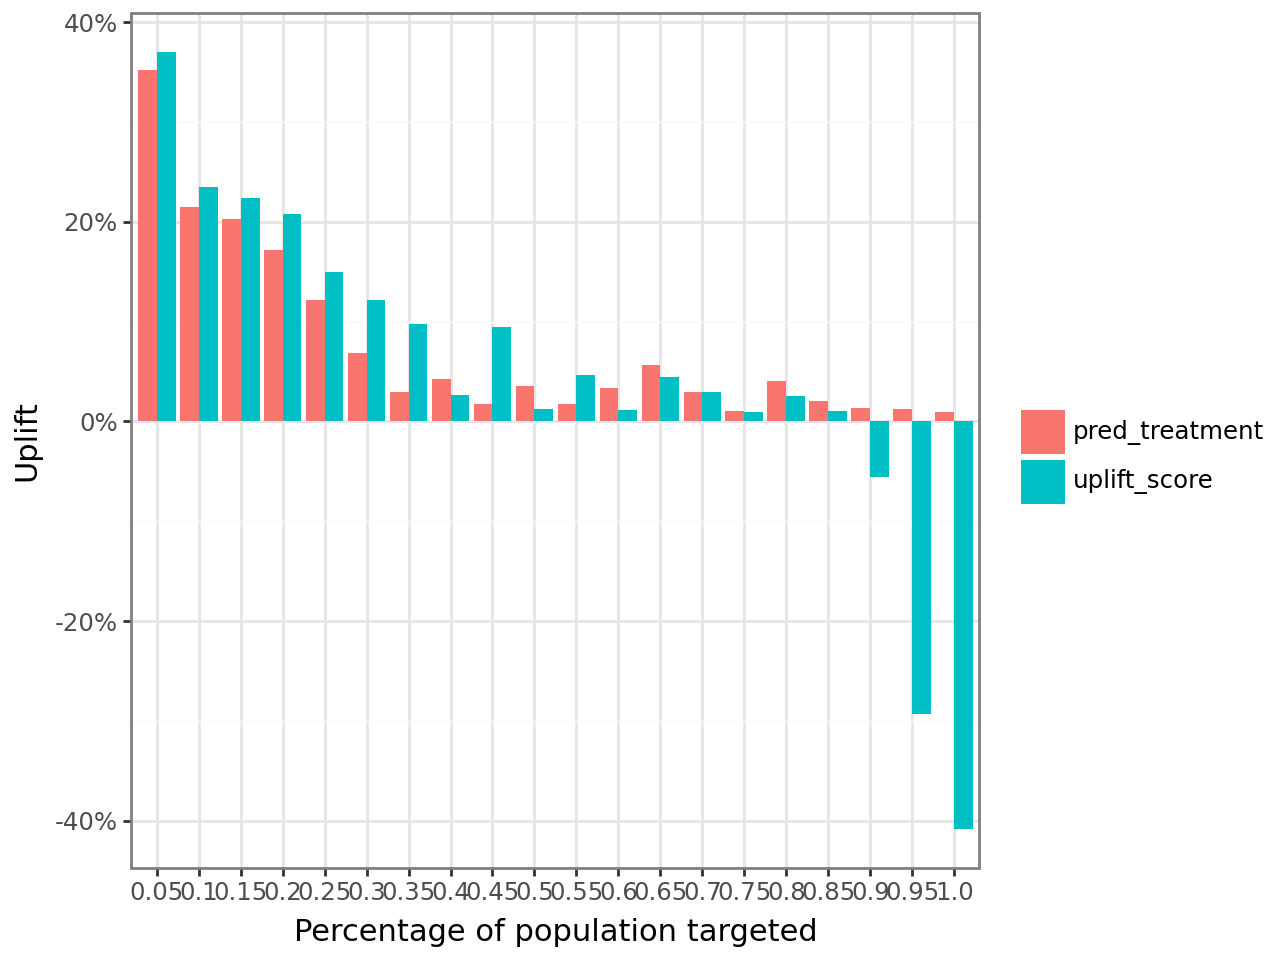

In [ ]:
rsm.model.uplift_plot(
    test_pred_rf,
    rvar="converted",
    lev="yes",
    pred=["pred_treatment", "uplift_score"],
    tvar="ad",
    tlev=1,
    qnt=20
)

When customers are ranked using the propensity score, uplift remains positive in early bins but is less concentrated compared to the uplift-based ranking. The distribution appears more uneven, indicating that the propensity approach captures purchase likelihood rather than true incremental impact.

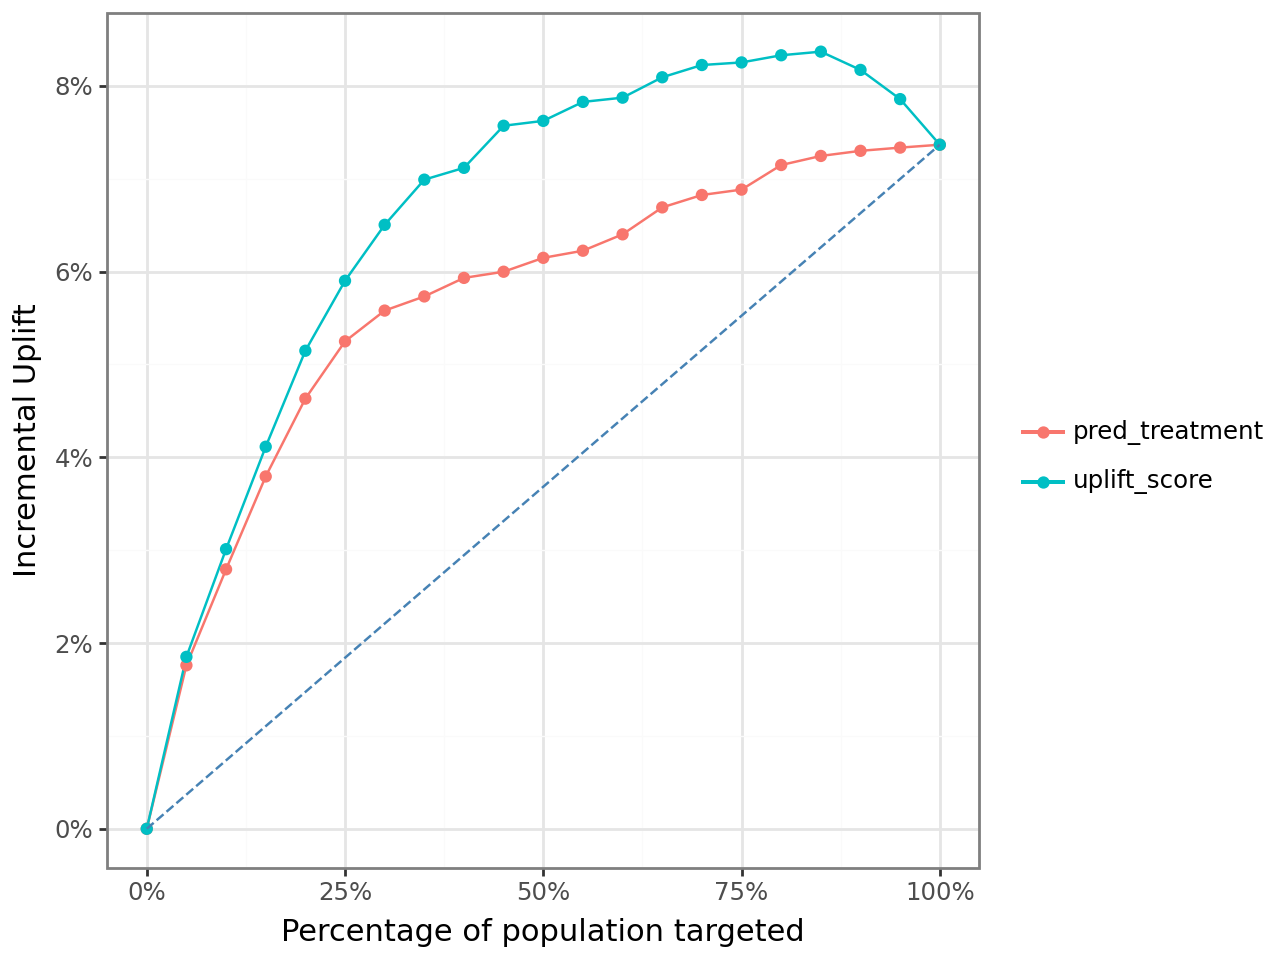

In [ ]:
rsm.model.inc_uplift_plot(
    test_pred_rf,
    rvar="converted",
    lev="yes",
    pred=["pred_treatment", "uplift_score"],
    tvar="ad",
    tlev=1,
    qnt=20
)

The incremental uplift curve under propensity ranking increases more gradually and stays closer to the baseline compared to the uplift model. Although it still improves over random targeting, it is less efficient in maximizing incremental response and profit than the uplift-based strategy.

In [195]:
row_prop_rf = (
    tab_prop_rf
    .with_columns((pl.col("cum_prop") - target_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_prop_rf = row_prop_rf.select("incremental_resp").item()
t_n_test_prop_rf = row_prop_rf.select("T_n").item()

inc_30000_prop_rf = inc_test_prop_rf * (target_customers / t_n_test_prop_rf)

profit_prop_rf = inc_30000_prop_rf * revenue_per_sale - target_customers * cost_per_target

print("RF Propensity profit:", profit_prop_rf)
print("Extra profit (RF uplift - propensity):", profit_rf - profit_prop_rf)

RF Propensity profit: 49420.497247706415
Extra profit (RF uplift - propensity): 11734.584766682063


#### I.9 Uplift with XGBoost

In [196]:
import polars as pl
import numpy as np
import pyrsm as rsm

from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

In [197]:
# Confirm stacked data exists

cg_rct_stacked.head()

converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,TimesLostSpaceship,TimesKilled,TimesCaptain,TimesNavigator,PurchasedCoinPackSmall,PurchasedCoinPackLarge,NumAdsClicked,DaysUser,UserConsole,UserHasOldOS,ad,training,test_size,random_state,pred_treatment,pred_control,uplift_score
cat,i32,i32,i32,i32,i32,i32,i32,cat,cat,i32,i32,i32,i32,cat,cat,i32,i32,cat,cat,i32,i64,f64,i32,f64,f64,f64
"""no""",7,18,0,124,0,81,0,"""yes""","""no""",8,0,0,4,"""no""","""yes""",3,2101,"""no""","""no""",0,1,0.3,1234,0.081256,0.019853,0.061404
"""no""",10,3,2,60,0,18,479,"""no""","""no""",10,7,0,0,"""yes""","""no""",7,1644,"""yes""","""no""",0,1,0.3,1234,0.183608,0.034446,0.149162
"""no""",2,1,0,0,0,0,0,"""no""","""no""",0,0,0,2,"""no""","""no""",8,3197,"""yes""","""yes""",0,1,0.3,1234,0.049103,0.01175,0.037353
"""no""",2,11,1,125,0,73,217,"""no""","""no""",0,0,0,0,"""yes""","""no""",6,913,"""no""","""no""",0,0,0.3,1234,0.091106,0.010709,0.080397
"""no""",8,15,0,0,0,6,51,"""yes""","""no""",0,0,2,1,"""yes""","""no""",21,2009,"""yes""","""no""",0,1,0.3,1234,0.308857,0.084095,0.224762


In [198]:
# Check training split balance

cg_rct_stacked.group_by(["converted", "ad", "training"]).len()

converted,ad,training,len
cat,i32,i64,u32
"""yes""",1,1,3130
"""no""",0,0,5659
"""no""",0,1,22635
"""no""",1,0,5217
"""yes""",1,0,783
"""yes""",0,0,341
"""yes""",0,1,1365
"""no""",1,1,20870


In [199]:
# Check proportions within ad × training

counts = cg_rct_stacked.group_by(["converted", "ad", "training"]).len()
totals = cg_rct_stacked.group_by(["ad", "training"]).len().rename({"len": "total"})

(
    counts.join(totals, on=["ad", "training"])
    .with_columns((pl.col("len") / pl.col("total")).alias("prop"))
    .sort(["ad", "training", "converted"])
)

converted,ad,training,len,total,prop
cat,i32,i64,u32,u32,f64
"""no""",0,0,5659,6000,0.943167
"""yes""",0,0,341,6000,0.056833
"""no""",0,1,22635,24000,0.943125
"""yes""",0,1,1365,24000,0.056875
"""no""",1,0,5217,6000,0.8695
"""yes""",1,0,783,6000,0.1305
"""no""",1,1,20870,24000,0.869583
"""yes""",1,1,3130,24000,0.130417


In [200]:
#Train/Test sizes

cg_rct_stacked.group_by("training").len()

training,len
i64,u32
1,48000
0,12000


In [201]:
# Split training data

train = cg_rct_stacked.filter(pl.col("training") == 1)

train_treat = train.filter(pl.col("ad") == 1)
train_ctrl  = train.filter(pl.col("ad") == 0)

In [202]:
# Define feature list

drop_cols = [
    "converted", "ad", "training",
    "pred_treatment", "pred_control", "uplift_score",
    "pred_treatment_xgb", "pred_control_xgb", "uplift_score_xgb"
]

evar = [c for c in cg_rct_stacked.columns if c not in drop_cols]

evar

['GameLevel',
 'NumGameDays',
 'NumGameDays4Plus',
 'NumInGameMessagesSent',
 'NumSpaceHeroBadges',
 'NumFriendRequestIgnored',
 'NumFriends',
 'AcquiredSpaceship',
 'AcquiredIonWeapon',
 'TimesLostSpaceship',
 'TimesKilled',
 'TimesCaptain',
 'TimesNavigator',
 'PurchasedCoinPackSmall',
 'PurchasedCoinPackLarge',
 'NumAdsClicked',
 'DaysUser',
 'UserConsole',
 'UserHasOldOS',
 'test_size',
 'random_state']

In [203]:
# Convert to numpy matrices

def to_numpy(df):
    return (
        df.select(evar)
          .with_columns(pl.selectors.categorical().to_physical())
          .with_columns(pl.all().cast(pl.Float32))
          .to_numpy()
    )

X_t = to_numpy(train_treat)
y_t = (train_treat["converted"] == "yes").to_numpy().astype(int)

X_c = to_numpy(train_ctrl)
y_c = (train_ctrl["converted"] == "yes").to_numpy().astype(int)

In [204]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "min_child_weight": [1, 5]
}

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1234
)

grid_treat = GridSearchCV(
    estimator=XGBClassifier(
        random_state=1234,
        eval_metric="logloss",
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

grid_treat.fit(X_t, y_t)

best_params_treat = grid_treat.best_params_
print("Best params (treatment):", best_params_treat)

grid_ctrl = GridSearchCV(
    estimator=XGBClassifier(
        random_state=1234,
        eval_metric="logloss",
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

grid_ctrl.fit(X_c, y_c)

best_params_ctrl = grid_ctrl.best_params_
print("Best params (control):", best_params_ctrl)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params (treatment): {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 50}
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params (control): {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200}


In [205]:
# Train treatment model

xgb_treat = XGBClassifier(
    **best_params_treat,
    random_state=1234,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_treat.fit(X_t, y_t)

xgb_treat

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [206]:
# Train control model

xgb_ctrl = XGBClassifier(
    **best_params_ctrl,
    random_state=1234,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_ctrl.fit(X_c, y_c)

xgb_ctrl

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [207]:
# Predict treatment probabilities

X_all = to_numpy(cg_rct_stacked)

pred_t = xgb_treat.predict_proba(X_all)[:, 1]

cg_rct_stacked = cg_rct_stacked.with_columns(
    pl.Series("pred_treatment_xgb", pred_t)
)

cg_rct_stacked.select("pred_treatment_xgb").head()

pred_treatment_xgb
f32
0.007427
0.204067
0.049137
0.090085
0.27798


In [208]:
#  Predict control probabilities

pred_c = xgb_ctrl.predict_proba(X_all)[:, 1]

cg_rct_stacked = cg_rct_stacked.with_columns(
    pl.Series("pred_control_xgb", pred_c)
)

cg_rct_stacked.select("pred_control_xgb").head()

pred_control_xgb
f32
0.002668
0.025578
0.004237
0.019915
0.042084


In [209]:
# Compute uplift score

cg_rct_stacked = cg_rct_stacked.with_columns(
    (pl.col("pred_treatment_xgb") - pl.col("pred_control_xgb"))
    .alias("uplift_score_xgb")
)

cg_rct_stacked.select("uplift_score_xgb").head()

uplift_score_xgb
f32
0.004759
0.178489
0.044899
0.070171
0.235896


In [210]:
# Define test set

test = cg_rct_stacked.filter(pl.col("training") == 0)

In [ ]:
# Uplift table

tab_uplift_xgb = rsm.model.uplift_tab(
    test,
    "converted",
    "yes",
    "uplift_score_xgb",
    "ad",
    1,
    qnt=20
)

tab_uplift_xgb

pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
str,i64,f64,u32,u32,u32,u32,f64,f64,f64
"""uplift_score_xgb""",1,0.05,138,300,53,410,99.219512,1.653659,0.330732
"""uplift_score_xgb""",2,0.1,232,600,76,739,170.294993,2.83825,0.243425
"""uplift_score_xgb""",3,0.15,309,900,92,1066,231.326454,3.855441,0.207737
"""uplift_score_xgb""",4,0.2,390,1200,110,1426,297.43338,4.957223,0.22
"""uplift_score_xgb""",5,0.25,443,1500,125,1730,334.618497,5.576975,0.127325
…,…,…,…,…,…,…,…,…,…
"""uplift_score_xgb""",16,0.8,696,4800,204,5239,509.094102,8.484902,0.013015
"""uplift_score_xgb""",17,0.85,703,5100,206,5544,513.497835,8.558297,0.016776
"""uplift_score_xgb""",18,0.9,732,5400,247,5791,501.677085,8.361285,-0.069325


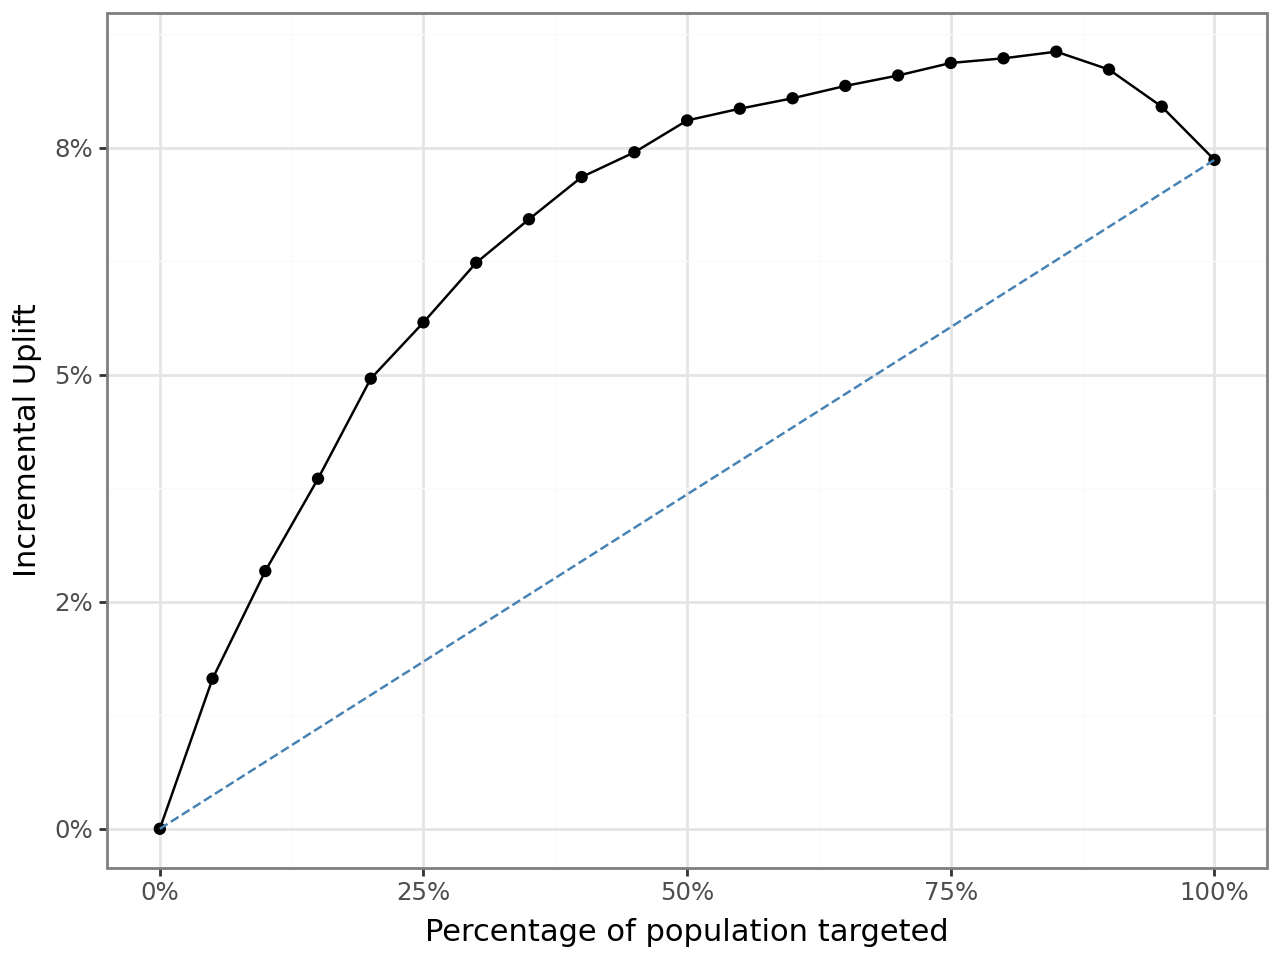

In [ ]:
rsm.model.inc_uplift_plot(
    test,
    "converted",
    "yes",
    "uplift_score_xgb",
    "ad",
    1,
    qnt=20
)

The uplift curve lies significantly above the random baseline, indicating that the model effectively ranks customers by their incremental responsiveness.
The steep increase in the first 30–40% suggests strong identification of persuadable customers.
After approximately 75%, the incremental uplift plateaus and begins to decline, implying diminishing returns from targeting additional customers.

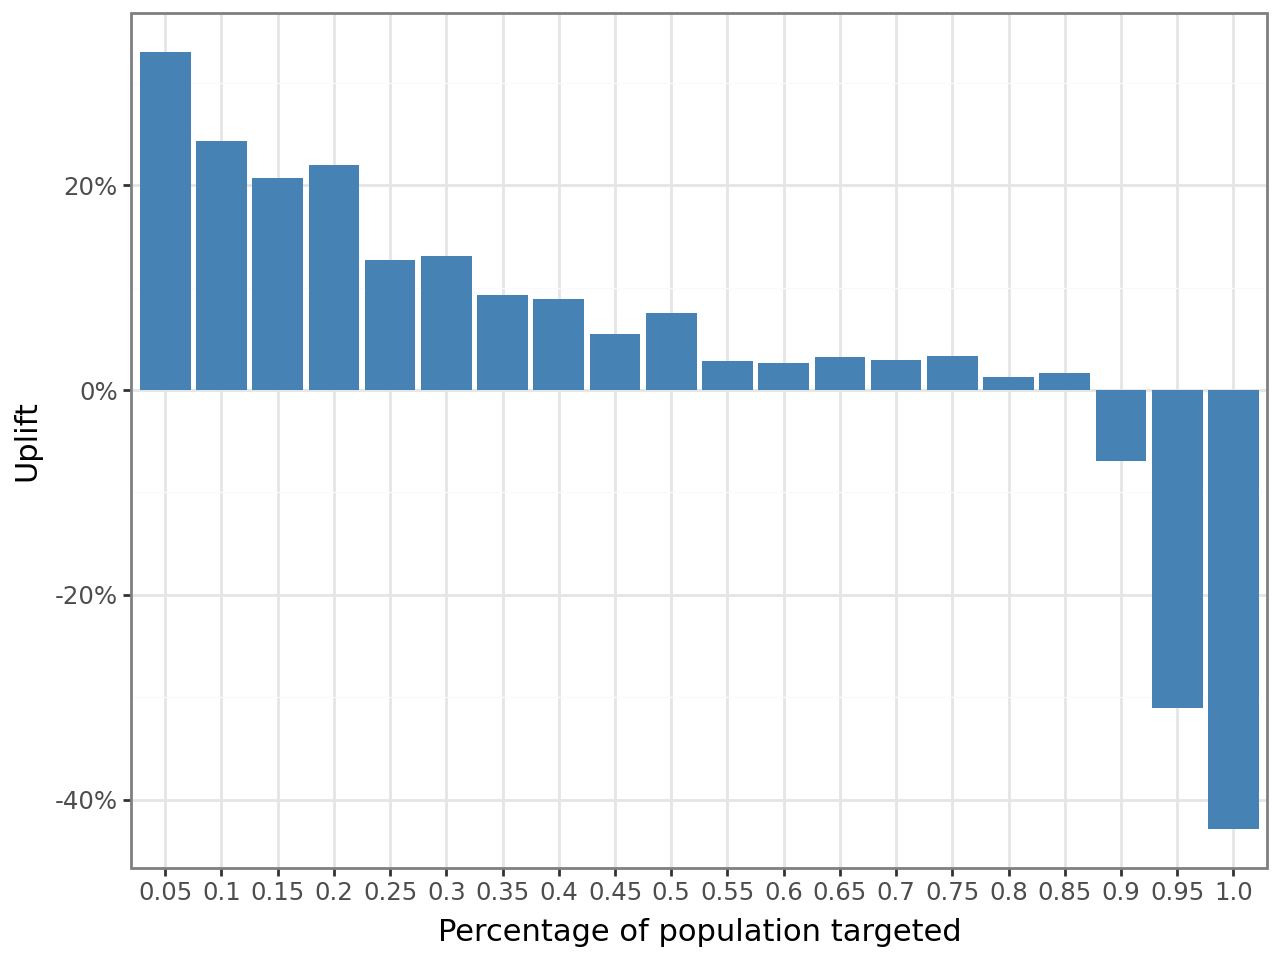

In [213]:
rsm.model.uplift_plot(
    test,
    "converted",
    "yes",
    "uplift_score_xgb",
    "ad",
    1,
    qnt=20
)

The decile uplift chart shows strong positive incremental effects in the top segments, confirming that the model effectively identifies persuadable customers.
The negative uplift in the bottom deciles indicates the presence of “do-not-disturb” customers who respond negatively to advertising.
This explains why targeting based on uplift yields substantially higher incremental profit compared to a propensity model.

In [ ]:
population_total = 120_000
target_customers = 30_000
revenue_per_sale = 14.99
cost_per_target = 1.50

target_prop = target_customers / population_total  # 0.25

row = (
    tab_uplift_xgb
    .with_columns((pl.col("cum_prop") - target_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test = row.select("incremental_resp").item()
t_n_test = row.select("T_n").item()

inc_30000 = inc_test * (target_customers / t_n_test)

revenue = inc_30000 * revenue_per_sale
cost = target_customers * cost_per_target
profit_xgb = revenue - cost

print("T_n at target in tab:", t_n_test)
print("Incremental purchases (extrapolated to 30,000):", inc_30000)
print("Incremental revenue:", revenue)
print("Cost:", cost)
print("Incremental profit (XGB):", profit_xgb)

T_n at target in tab: 1500
Incremental purchases (extrapolated to 30,000): 6692.369942196532
Incremental revenue: 100318.62543352602
Cost: 45000.0
Incremental profit (XGB): 55318.62543352602


In [215]:
#  Uplift table (propensity ranking)

tab_prop_xgb = rsm.model.uplift_tab(
    test,
    "converted",
    "yes",
    "pred_treatment_xgb",
    "ad",
    1,
    qnt=20
)

tab_prop_xgb

pred,bins,cum_prop,T_resp,T_n,C_resp,C_n,incremental_resp,inc_uplift,uplift
str,i64,f64,u32,u32,u32,u32,f64,f64,f64
"""pred_treatment_xgb""",1,0.05,149,300,60,392,103.081633,1.718027,0.343605
"""pred_treatment_xgb""",2,0.1,246,600,98,705,162.595745,2.709929,0.201928
"""pred_treatment_xgb""",3,0.15,321,900,124,1004,209.844622,3.49741,0.163043
"""pred_treatment_xgb""",4,0.2,388,1200,142,1314,258.319635,4.305327,0.165269
"""pred_treatment_xgb""",5,0.25,461,1500,176,1598,295.793492,4.929892,0.123615
…,…,…,…,…,…,…,…,…,…
"""pred_treatment_xgb""",16,0.8,759,4800,337,4814,422.980058,7.049668,0.023151
"""pred_treatment_xgb""",17,0.85,769,5100,337,5103,432.198119,7.203302,0.033333
"""pred_treatment_xgb""",18,0.9,772,5400,338,5383,432.932565,7.215543,0.006429


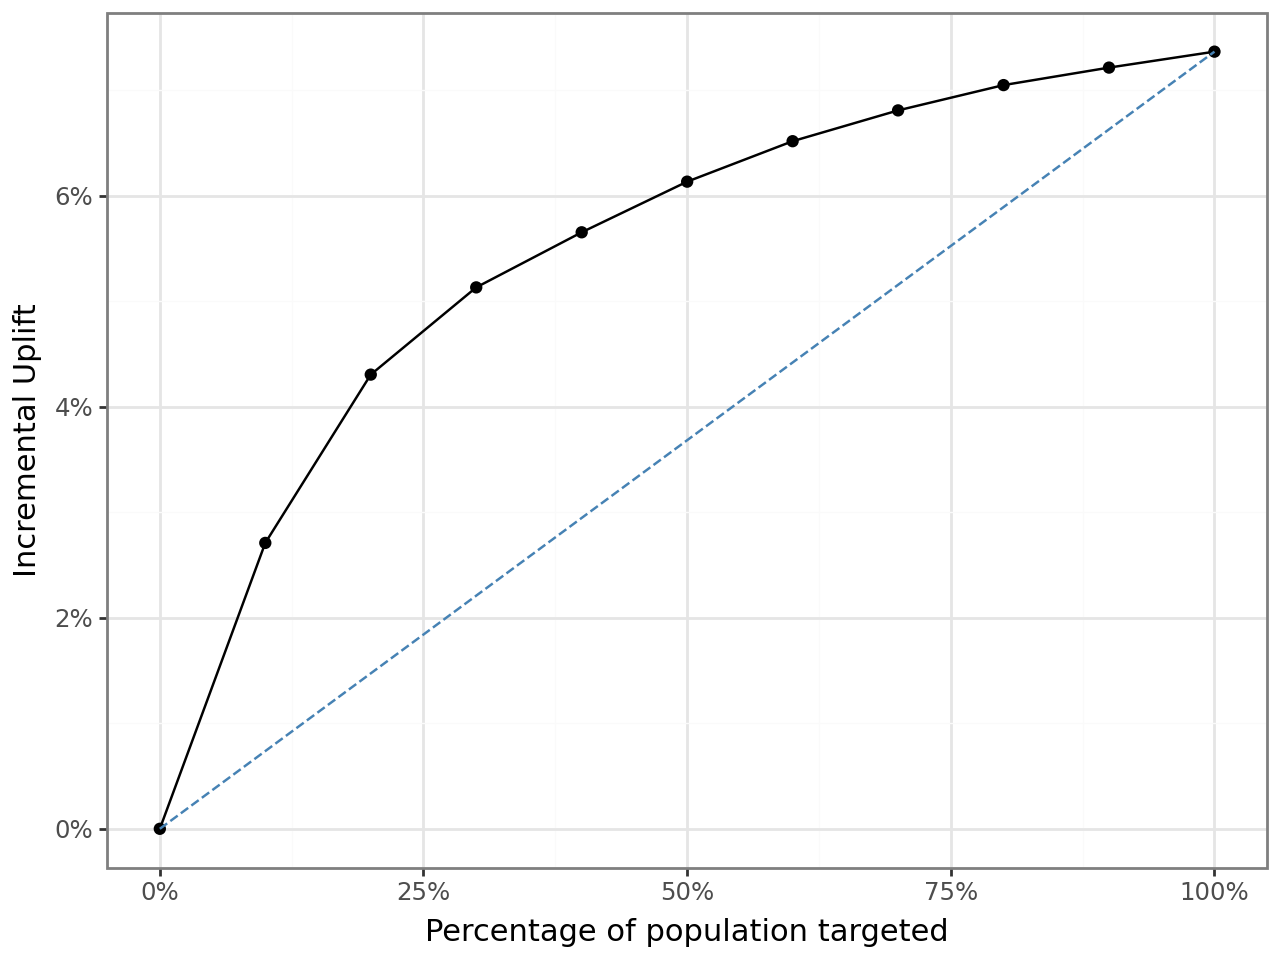

In [ ]:
#  Incremental uplift plot (propensity only)

rsm.model.inc_uplift_plot(
    test,
    "converted",
    "yes",
    "pred_treatment_xgb",
    "ad",
    1
)

The incremental uplift curve shows that the model performs better than random targeting across all targeting percentages. However, compared to the stronger model, the curve rises less steeply and reaches a lower maximum uplift, suggesting weaker identification of persuadable customers.

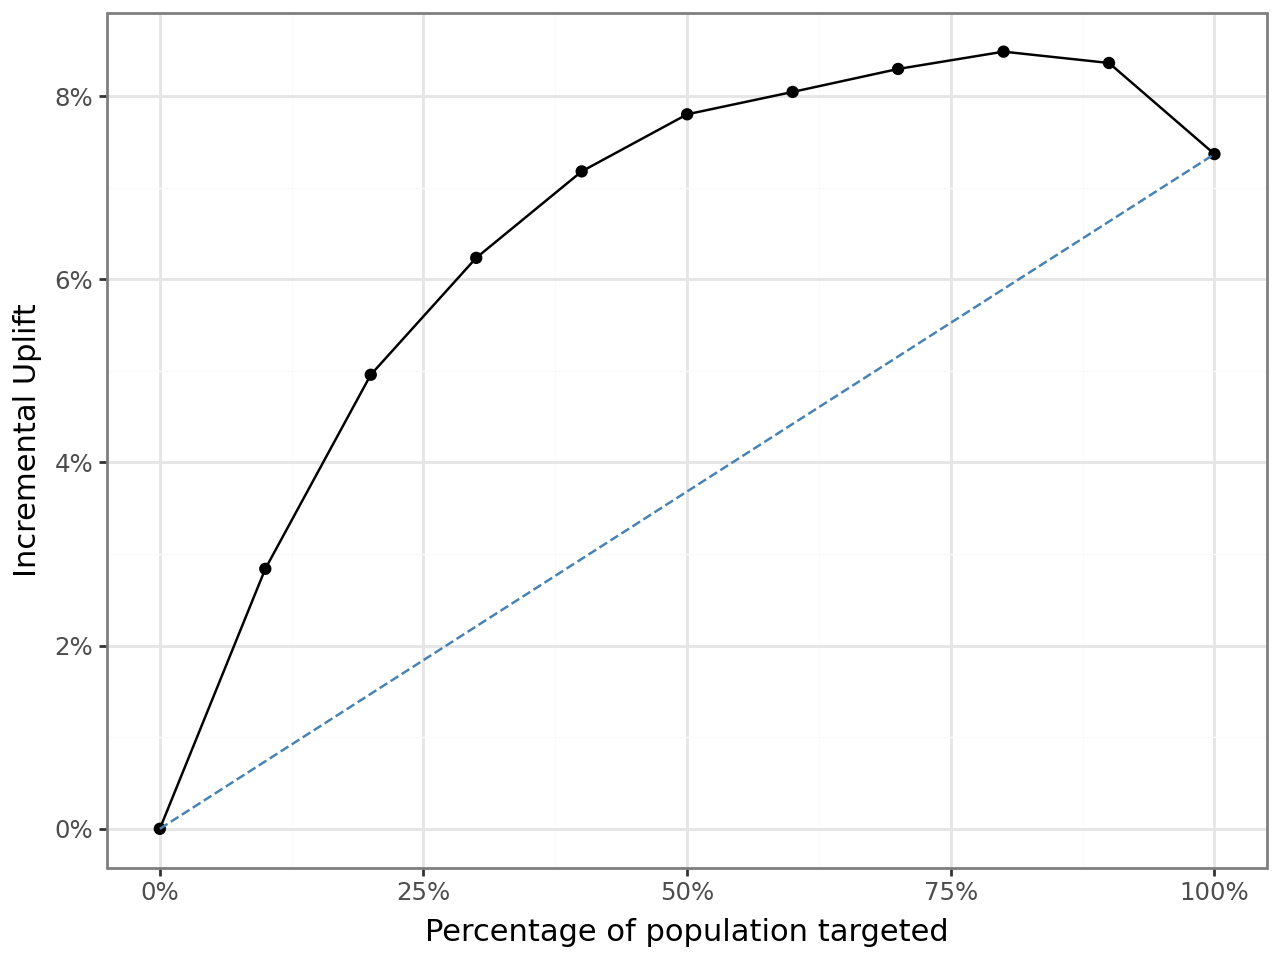

In [217]:
# Incremental uplift plot (uplift only)

rsm.model.inc_uplift_plot(
    test,
    "converted",
    "yes",
    "uplift_score_xgb",
    "ad",
    1
)

The uplift curve demonstrates strong ranking ability, with a steep increase in the top 20–30% of customers. The curve peaks around 80% before declining, indicating the presence of negative or zero-impact segments in the lower ranks. Compared to weaker models, this model achieves a higher maximum incremental uplift, suggesting superior identification of persuadable customers.

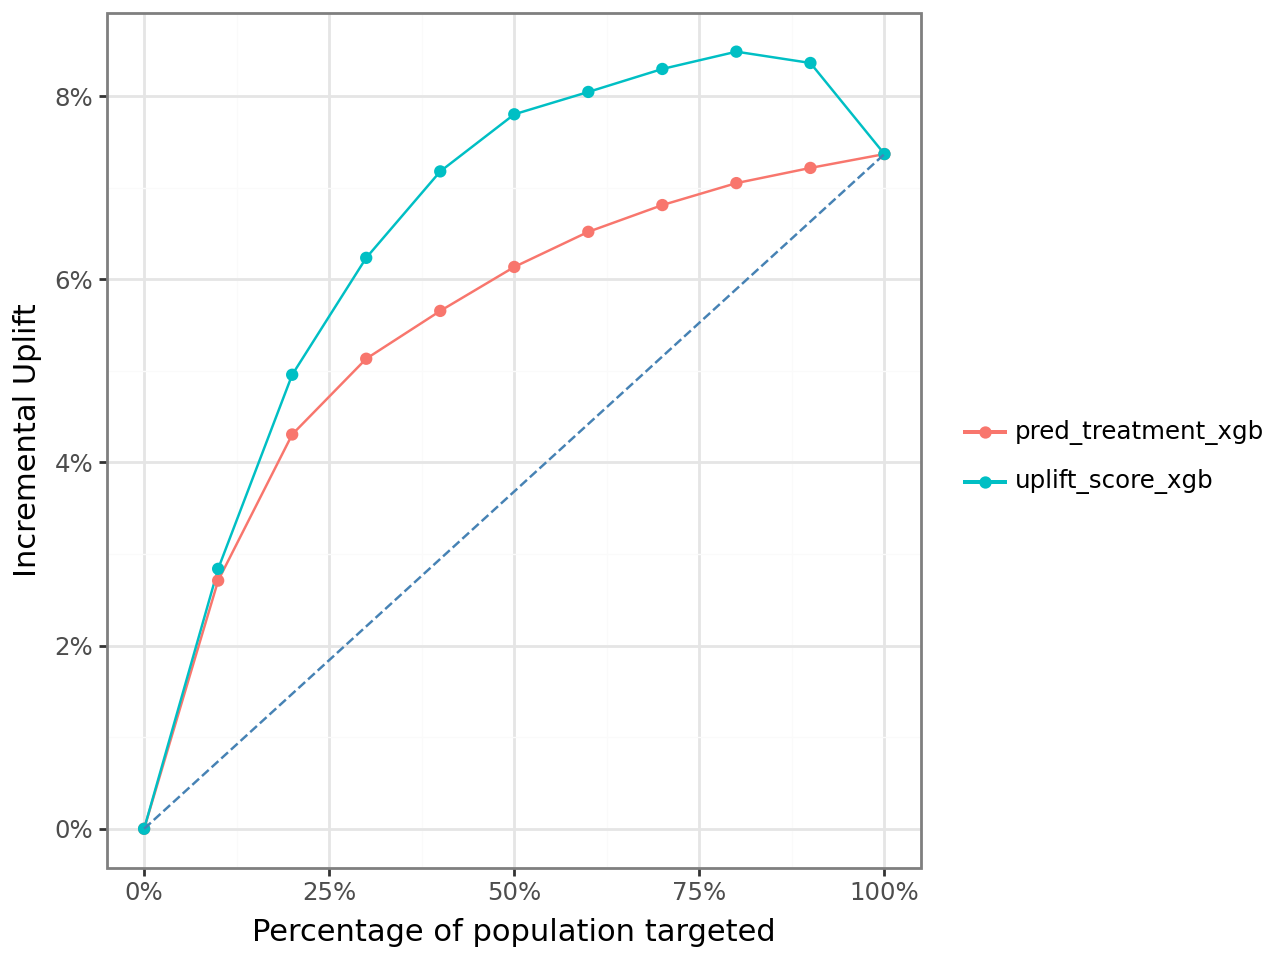

In [218]:
# Overlay incremental plot

rsm.model.inc_uplift_plot(
    test,
    "converted",
    "yes",
    ["pred_treatment_xgb", "uplift_score_xgb"],
    "ad",
    1
)

The uplift curve consistently dominates the propensity curve across all targeting levels. This indicates that ranking customers by incremental response leads to a higher concentration of persuadable customers in the targeted segment. In contrast, the propensity model prioritizes customers with high purchase probability regardless of treatment effect, leading to lower incremental gains. This explains the substantial incremental profit difference observed between the two approaches.


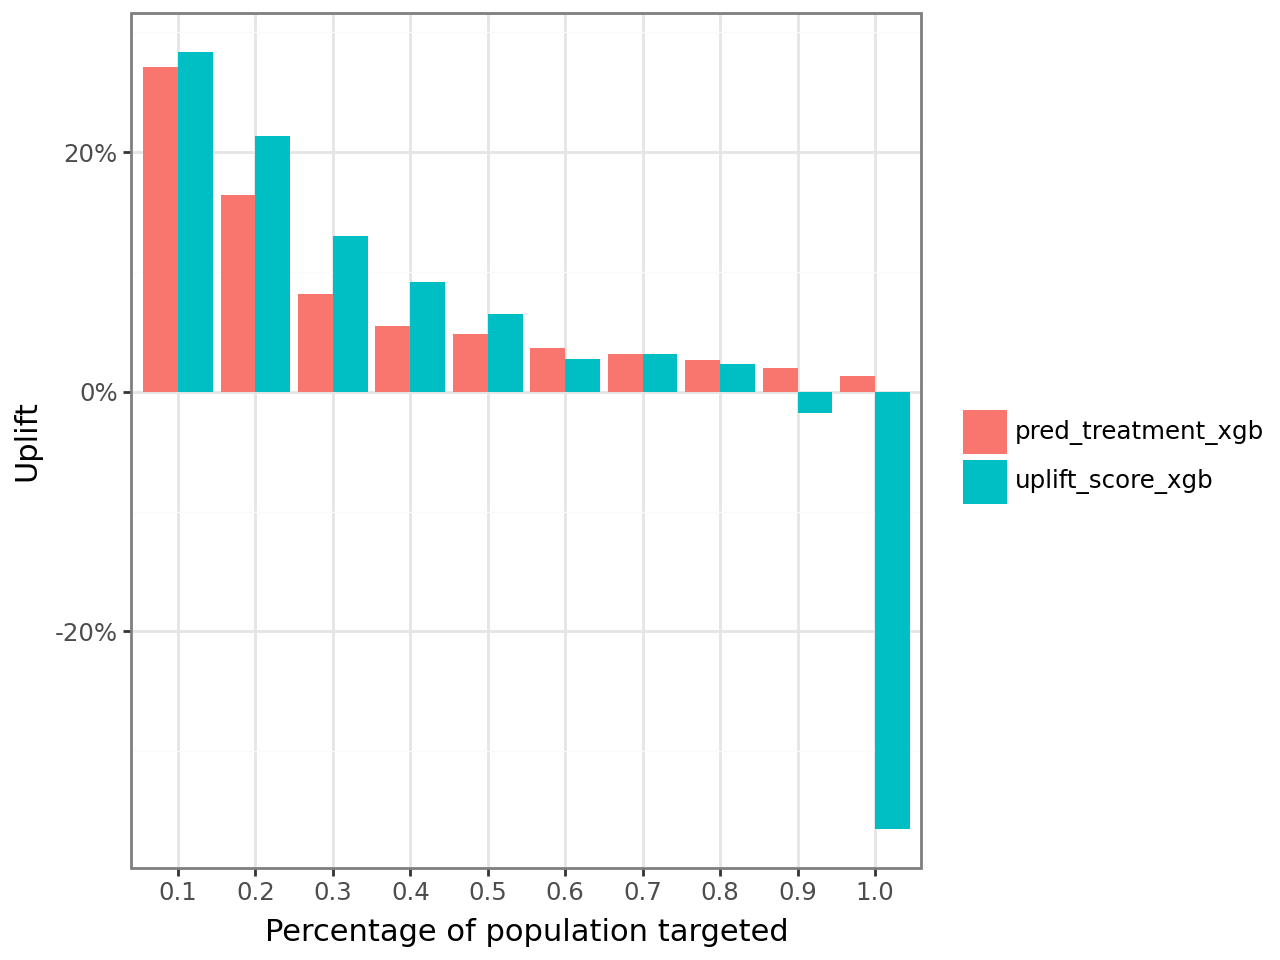

In [219]:
# Uplift plot (overlay)

rsm.model.uplift_plot(
    test,
    "converted",
    "yes",
    ["pred_treatment_xgb", "uplift_score_xgb"],
    "ad",
    1
)

The decile uplift comparison shows that the uplift model concentrates significantly higher incremental effects in the top-ranked segments compared to the propensity model. While both models perform similarly in the highest decile, the uplift model maintains stronger incremental gains across the top 30–40% of the population. Additionally, the uplift model pushes strongly negative-response customers into the lowest deciles, thereby avoiding losses when targeting a subset of customers. This explains the substantial incremental profit advantage of the uplift model.


In [220]:
# Correlation summary
test.select([
    pl.corr("pred_treatment_xgb", "pred_control_xgb").alias("corr_treat_control"),
    pl.corr("pred_treatment_xgb", "uplift_score_xgb").alias("corr_treat_uplift"),
    pl.corr("pred_control_xgb", "uplift_score_xgb").alias("corr_control_uplift")
])


corr_treat_control,corr_treat_uplift,corr_control_uplift
f32,f32,f32
0.290689,0.59748,-0.593576


In [221]:
test_data_xgb = cg_rct_stacked.filter(pl.col("training") == 0) \
    .select(["pred_treatment_xgb",
             "pred_control_xgb",
             "uplift_score_xgb"])

cm_xgb = rsm.basics.correlation(
    {"test_data_xgb": test_data_xgb}
)

cm_xgb.summary()

Correlation
Data     : test_data_xgb
Method   : pearson
Cutoff   : 0
Variables: pred_treatment_xgb, pred_control_xgb, uplift_score_xgb
Null hyp.: variables x and y are not correlated
Alt. hyp.: variables x and y are correlated

Correlation matrix:
┌──────────────────┬────────────────────┬──────────────────┐
│                  ┆ pred_treatment_xgb ┆ pred_control_xgb │
╞══════════════════╪════════════════════╪══════════════════╡
│ pred_control_xgb ┆ 0.29               ┆                  │
│ uplift_score_xgb ┆ 0.6                ┆ -0.59            │
└──────────────────┴────────────────────┴──────────────────┘

p.values:
┌──────────────────┬────────────────────┬──────────────────┐
│                  ┆ pred_treatment_xgb ┆ pred_control_xgb │
╞══════════════════╪════════════════════╪══════════════════╡
│ pred_control_xgb ┆ 0.0                ┆                  │
│ uplift_score_xgb ┆ 0.0                ┆ 0.0              │
└──────────────────┴────────────────────┴──────────────────┘


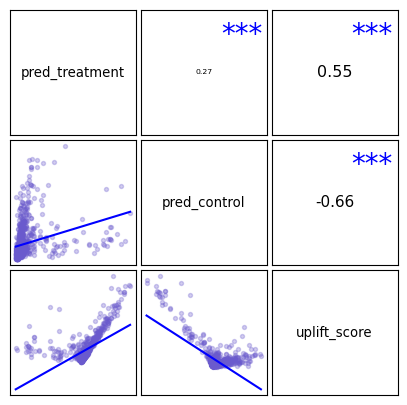

In [222]:
cm.plot()

The uplift score exhibits a strong positive correlation with predicted treatment response and a strong negative correlation with predicted control response. This confirms that the model effectively captures heterogeneous treatment effects rather than merely predicting purchase probability. The relatively low correlation between treatment and control predictions further indicates meaningful differentiation in individual-level causal effects.

In [223]:
target_customers = 30000

# test set size in "ad==1" group (treated) inside cg_rct_stacked
treat_test = cg_rct_stacked.filter((pl.col("training") == 0) & (pl.col("ad") == 1))
n_treat_test = treat_test.height

target_rate = 30000 / 120000

row_x = (
    tab_uplift_xgb.with_columns(
        (pl.col("T_n") / n_treat_test - target_rate).abs().alias("diff")
    )
    .sort("diff")
    .head(1)
)

inc_test = row_x.select("incremental_resp").item()
T_n_row  = row_x.select("T_n").item()

inc_30000 = inc_test * (target_customers / T_n_row)

revenue_per_sale = 14.99
cost_per_target = 1.50

profit_xgb = inc_30000 * revenue_per_sale - target_customers * cost_per_target
print("XGBoost incremental profit targeting best 30,000:", profit_xgb)

row_p = (
    tab_prop_xgb
    .with_columns((pl.col("cum_prop") - target_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_p = row_p.select("incremental_resp").item()
t_n_test_p = row_p.select("T_n").item()

inc_30000_p = inc_test_p * (target_customers / t_n_test_p)

revenue_p = inc_30000_p * revenue_per_sale
cost_p = target_customers * cost_per_target
profit_xgb_prop = revenue_p - cost_p

print("Propensity (XGB) profit:", profit_xgb_prop)

extra_profit_xgb = profit_xgb - profit_xgb_prop
print("Extra profit (uplift - propensity):", extra_profit_xgb)

XGBoost incremental profit targeting best 30,000: 55318.62543352602
Propensity (XGB) profit: 43678.88886107635
Extra profit (uplift - propensity): 11639.736572449663


#### II.1

In [224]:
breakeven = cost_per_target / revenue_per_sale
treat_test = cg_rct_stacked.filter((pl.col("training") == 0) & (pl.col("ad") == 1))

pct_target = treat_test.select(
    (pl.col("pred_treatment") >= breakeven).mean().alias("pct_target")
).item()

print("Breakeven:", breakeven)
print("Target % in ad treatment test set (propensity):", pct_target)

Breakeven: 0.1000667111407605
Target % in ad treatment test set (propensity): 0.48483333333333334


*Formula to target customers:*
$$
P(Y=1|ad=1,X_i) \ge \frac{cost\_per\_target}{revenue\_per\_sale}
$$
About 48.48% customers I would target.



#### II.2

In [225]:
treat_test = cg_rct_stacked.filter((pl.col("training") == 0) & (pl.col("ad") == 1))

pct_target_uplift = treat_test.select(
    (pl.col("uplift_score") >= breakeven).mean().alias("pct_target")
).item()

print("Breakeven:", breakeven)
print("Target % in ad treatment test set (uplift):", pct_target_uplift)


Breakeven: 0.1000667111407605
Target % in ad treatment test set (uplift): 0.2195


*Formula to target customers:*
$$
u_i = P(Y=1 \mid ad=1, X_i) - P(Y=1 \mid ad=0, X_i)
$$
$$
u_i \ge \frac{cost\_per\_target}{revenue\_per\_sale}
$$


#### II.3

In [226]:
pct_propensity = pct_target
pct_uplift = pct_target_uplift


def round_to_5pct(x):
    return round(x / 0.05) * 0.05


opt_propensity = round_to_5pct(pct_propensity)
opt_uplift = round_to_5pct(pct_uplift)

In [227]:
target_customers_prop = int(population_total * opt_propensity)
target_prop_prop = target_customers_prop / population_total

row_p = (
    tab_prop.with_columns((pl.col("cum_prop") - target_prop_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_p = row_p.select("incremental_resp").item()
t_n_test_p = row_p.select("T_n").item()

inc_pop_p = inc_test_p * (target_customers_prop / t_n_test_p)

revenue_p = inc_pop_p * revenue_per_sale
cost_p = target_customers_prop * cost_per_target
profit_p = revenue_p - cost_p

print("Propensity optimal target customers:", target_customers_prop)
print("Propensity incremental profit (optimal %):", profit_p)


Propensity optimal target customers: 60000
Propensity incremental profit (optimal %): 3199.660060261129


In [228]:
target_customers_u = int(population_total * opt_uplift)
target_prop_u = target_customers_u / population_total

row_u = (
    tab_uplift.with_columns((pl.col("cum_prop") - target_prop_u).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_u = row_u.select("incremental_resp").item()
t_n_test_u = row_u.select("T_n").item()

inc_pop_u = inc_test_u * (target_customers_u / t_n_test_u)

revenue_u = inc_pop_u * revenue_per_sale
cost_u = target_customers_u * cost_per_target
profit_u = revenue_u - cost_u

print("Uplift optimal target customers:", target_customers_u)
print("Uplift incremental profit (optimal %):", profit_u)


Uplift optimal target customers: 24000
Uplift incremental profit (optimal %): 44290.08397790056


In [229]:
print("Extra profit (uplift - propensity) at optimal %:", profit_u - profit_p)


Extra profit (uplift - propensity) at optimal %: 41090.42391763943


#### II.4

In [230]:
breakeven = cost_per_target / revenue_per_sale

treat_test_nn = test_pred.filter(pl.col("ad") == 1)

pct_target_nn_prop = treat_test_nn.select(
    (pl.col("pred_treatment") >= breakeven).mean().alias("pct_target")
).item()

print("Breakeven:", breakeven)
print("Target % in ad treatment test set (NN propensity):", pct_target_nn_prop)


Breakeven: 0.1000667111407605
Target % in ad treatment test set (NN propensity): 0.43366666666666664


In [231]:
pct_target_nn_uplift = treat_test_nn.select(
    (pl.col("uplift_score") >= breakeven).mean().alias("pct_target")
).item()

print("Target % in ad treatment test set (NN uplift):", pct_target_nn_uplift)

Target % in ad treatment test set (NN uplift): 0.239


In [232]:
def round_to_5pct(x):
    return round(x / 0.05) * 0.05

opt_nn_prop = round_to_5pct(pct_target_nn_prop)
opt_nn_uplift = round_to_5pct(pct_target_nn_uplift)

print("Rounded NN Propensity %:", opt_nn_prop)
print("Rounded NN Uplift %:", opt_nn_uplift)

Rounded NN Propensity %: 0.45
Rounded NN Uplift %: 0.25


In [233]:
target_customers_nn_prop = int(population_total * opt_nn_prop)
target_prop_nn_prop = target_customers_nn_prop / population_total

row_nn_p = (
    tab_prop_mlp
    .with_columns((pl.col("cum_prop") - target_prop_nn_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_nn_p = row_nn_p.select("incremental_resp").item()
t_n_test_nn_p = row_nn_p.select("T_n").item()

inc_pop_nn_p = inc_test_nn_p * (target_customers_nn_prop / t_n_test_nn_p)

profit_nn_p = inc_pop_nn_p * revenue_per_sale - target_customers_nn_prop * cost_per_target

print("NN Propensity optimal customers:", target_customers_nn_prop)
print("NN Propensity incremental profit:", profit_nn_p)

NN Propensity optimal customers: 54000
NN Propensity incremental profit: 17928.734577387484


In [234]:
target_customers_nn_u = int(population_total * opt_nn_uplift)
target_prop_nn_u = target_customers_nn_u / population_total

row_nn_u = (
    tab_uplift_mlp
    .with_columns((pl.col("cum_prop") - target_prop_nn_u).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_nn_u = row_nn_u.select("incremental_resp").item()
t_n_test_nn_u = row_nn_u.select("T_n").item()

inc_pop_nn_u = inc_test_nn_u * (target_customers_nn_u / t_n_test_nn_u)

profit_nn_u = inc_pop_nn_u * revenue_per_sale - target_customers_nn_u * cost_per_target

print("NN Uplift optimal customers:", target_customers_nn_u)
print("NN Uplift incremental profit:", profit_nn_u)

NN Uplift optimal customers: 30000
NN Uplift incremental profit: 53626.582269904015


In [235]:
print("Extra profit (NN uplift - NN propensity):", profit_nn_u - profit_nn_p)

Extra profit (NN uplift - NN propensity): 35697.84769251653


#### II.5

In [236]:
breakeven = cost_per_target / revenue_per_sale

treat_test_rf = test_pred_rf.filter(pl.col("ad") == 1)

pct_target_rf_prop = treat_test_rf.select(
    (pl.col("pred_treatment") >= breakeven).mean().alias("pct_target")
).item()

print("Breakeven:", breakeven)
print("Target % in ad treatment test set (RF propensity):", pct_target_rf_prop)

Breakeven: 0.1000667111407605
Target % in ad treatment test set (RF propensity): 0.5053333333333333


In [237]:
pct_target_rf_uplift = treat_test_rf.select(
    (pl.col("uplift_score") >= breakeven).mean().alias("pct_target")
).item()

print("Target % in ad treatment test set (RF uplift):", pct_target_rf_uplift)

Target % in ad treatment test set (RF uplift): 0.29033333333333333


In [238]:
def round_to_5pct(x):
    return round(x / 0.05) * 0.05

opt_rf_prop = round_to_5pct(pct_target_rf_prop)
opt_rf_uplift = round_to_5pct(pct_target_rf_uplift)

print("Rounded RF Propensity %:", opt_rf_prop)
print("Rounded RF Uplift %:", opt_rf_uplift)

Rounded RF Propensity %: 0.5
Rounded RF Uplift %: 0.30000000000000004


In [239]:
target_customers_rf_prop = int(population_total * opt_rf_prop)
target_prop_rf_prop = target_customers_rf_prop / population_total

row_rf_p = (
    tab_prop_rf
    .with_columns((pl.col("cum_prop") - target_prop_rf_prop).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_rf_p = row_rf_p.select("incremental_resp").item()
t_n_test_rf_p = row_rf_p.select("T_n").item()

inc_pop_rf_p = inc_test_rf_p * (target_customers_rf_prop / t_n_test_rf_p)

profit_rf_p = inc_pop_rf_p * revenue_per_sale - target_customers_rf_prop * cost_per_target

print("RF Propensity optimal customers:", target_customers_rf_prop)
print("RF Propensity incremental profit:", profit_rf_p)

RF Propensity optimal customers: 60000
RF Propensity incremental profit: 20598.99980059822


In [240]:
target_customers_rf_u = int(population_total * opt_rf_uplift)
target_prop_rf_u = target_customers_rf_u / population_total

row_rf_u = (
    tab_uplift_rf
    .with_columns((pl.col("cum_prop") - target_prop_rf_u).abs().alias("diff"))
    .sort("diff")
    .head(1)
)

inc_test_rf_u = row_rf_u.select("incremental_resp").item()
t_n_test_rf_u = row_rf_u.select("T_n").item()

inc_pop_rf_u = inc_test_rf_u * (target_customers_rf_u / t_n_test_rf_u)

profit_rf_u = inc_pop_rf_u * revenue_per_sale - target_customers_rf_u * cost_per_target

print("RF Uplift optimal customers:", target_customers_rf_u)
print("RF Uplift incremental profit:", profit_rf_u)

RF Uplift optimal customers: 36000
RF Uplift incremental profit: 62994.89035863997


In [241]:
print("Extra profit (RF uplift - RF propensity):", profit_rf_u - profit_rf_p)

Extra profit (RF uplift - RF propensity): 42395.89055804175


#### II.6

In [245]:
population_total = 120_000
revenue_per_sale = 14.99
cost_per_target = 1.50

breakeven = cost_per_target / revenue_per_sale

print("Breakeven uplift:", breakeven)

Breakeven uplift: 0.1000667111407605


In [246]:
cg_test = cg_rct_stacked.filter(
    pl.col("training") == 0
)

print("Test set size:", cg_test.height)

Test set size: 12000


In [247]:
cg_test = cg_test.with_columns([
    # Uplift profit
    (pl.col("uplift_score_xgb") * revenue_per_sale - cost_per_target)
        .alias("profit_score_uplift"),

    # Propensity profit
    (pl.col("pred_treatment_xgb") * revenue_per_sale - cost_per_target)
        .alias("profit_score_prop")
])

In [248]:
prop_targets = cg_test.filter(
    pl.col("profit_score_prop") > 0
)

target_customers_prop_test = prop_targets.height

In [249]:
inc_prop_test = prop_targets.select(
    (pl.col("pred_treatment_xgb") - pl.col("pred_control_xgb")).sum()
).item()

revenue_prop_test = inc_prop_test * revenue_per_sale
cost_prop_test = target_customers_prop_test * cost_per_target

profit_prop_test = revenue_prop_test - cost_prop_test

In [250]:
scale_factor = population_total / cg_test.height

target_customers_prop = int(target_customers_prop_test * scale_factor)
profit_prop_population = profit_prop_test * scale_factor

In [251]:
uplift_targets = cg_test.filter(
    pl.col("profit_score_uplift") > 0
)

target_customers_upl_test = uplift_targets.height

In [252]:
inc_upl_test = uplift_targets.select(
    pl.col("uplift_score_xgb").sum()
).item()

revenue_upl_test = inc_upl_test * revenue_per_sale
cost_upl_test = target_customers_upl_test * cost_per_target

profit_upl_test = revenue_upl_test - cost_upl_test

In [253]:
target_customers_upl = int(target_customers_upl_test * scale_factor)
profit_upl_population = profit_upl_test * scale_factor

In [254]:
print("Propensity optimal target customers:", target_customers_prop)
print("Propensity incremental profit (optimal %):",
      profit_prop_population)

print("Uplift optimal target customers:", target_customers_upl)
print("Uplift incremental profit (optimal %):",
      profit_upl_population)

print("Extra profit (uplift - propensity):",
      profit_upl_population - profit_prop_population)

Propensity optimal target customers: 60300
Propensity incremental profit (optimal %): 8145.993066406245
Uplift optimal target customers: 36660
Uplift incremental profit (optimal %): 59945.59627075196
Extra profit (uplift - propensity): 51799.60320434571


#### II.7 Reason

Reason 1: Uplift targets incremental impact, not purchase probability

A propensity-to-buy model ranks customers based on their overall likelihood of purchasing under treatment, i.e., P(Y=1 \mid ad=1). However, this does not measure the causal impact of the advertisement.

Customers with high purchase probability may have purchased even without the ad (i.e., “sure things”). Targeting such customers increases cost but does not generate incremental revenue.

In contrast, the uplift model ranks customers based on:

P(Y=1 ｜ ad=1) - P(Y=1 ｜ ad=0)

which directly estimates the incremental effect of advertising. Therefore, uplift targeting prioritizes customers whose behavior is changed by the ad, leading to higher incremental profit.

Reason 2: Uplift avoids negative and zero-impact segments

Customers can be categorized into four behavioral segments:
	•	Persuadables (buy only if treated)
	•	Sure things (buy regardless of treatment)
	•	Lost causes (do not buy regardless)
	•	Do-not-disturbs (less likely to buy if treated)

A propensity model tends to rank “sure things” highly because they have high purchase probability. However, targeting them yields little or no incremental profit.

Moreover, propensity models may also target “do-not-disturb” customers, resulting in negative incremental profit.

An uplift model explicitly identifies and ranks persuadables higher while pushing sure things and negative-impact customers lower in the ranking. When targeting the optimal percentage of customers, this leads to a higher concentration of persuadables in the selected group and thus greater incremental profit.